In [44]:
# Importing the libraries
import os 
import sys
import time
import warnings
os.system('clear')
warnings.filterwarnings("ignore")
import argparse

import torch 
# import torch.nn as nn
# import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
torch.set_printoptions(threshold=512, linewidth=512)

hostname = os.uname()
if 'tycho' in hostname:
    # Common folder is already in the path
    pass
elif 'tedtop' in hostname:
    print('Setting up paths for tedtop')
    sys.path.append('/home/fedor-tairli/work/CDEs/Dataset/')
elif 'ycho' in hostname: 
    sys.path.append('/remote/tychodata/ftairli/work/Projects/Common/')
else:
    # Assume KIT CLuster
    sys.path.append('/cr/work/tairli/CDEs/Dataset/')



In [45]:
def in_jupyter():
    try:
        from IPython import get_ipython
        shell = get_ipython().__class__.__name__
        return shell == "ZMQInteractiveShell"
    except:
        return False

print(f'Running in Jupyter: {in_jupyter()}')

Running in Jupyter: True


In [46]:
print(f' Cuda is available: {torch.cuda.is_available()}')

 Cuda is available: True


In [47]:
ModelPath = os.path.abspath('../Models') + '/'
sys.path.append(ModelPath)
# Dataset modules
from Dataset2 import DatasetContainer, ProcessingDatasetContainer
from DataGenFunctions import Pass_Main,Pass_Aux,Pass_Truth,Pass_Rec,Pass_Graph,Pass_MetaData,Clean_Data

def LoadProcessingDataset(Path_To_Data,Path_To_Proc_Data,RunNames,RecalculateDataset = False,NeedTraces = False,OptionalName = None):
    if OptionalName is None: OptionalName = 'CurrentProcessingDataset'
    '''Loads the dataset from the path and returns a ProcessingDatasetContainer'''
    # Check if path to data endswith '/'
    if Path_To_Data     .endswith('/'):Path_To_Data      = Path_To_Data[:-1]
    if Path_To_Proc_Data.endswith('/'):Path_To_Proc_Data = Path_To_Proc_Data[:-1]
    
    
    if (not RecalculateDataset) and (os.path.exists(Path_To_Proc_Data+f'/{OptionalName}.pt')):
        print(f'Loading Dataset {OptionalName}')
        Dataset = torch.load(Path_To_Proc_Data+f'/{OptionalName}.pt', weights_only=False)
        # Dataset.Truth_Keys = ('x','y','z','SDPPhi','CEDist')
        # Dataset.Truth_Units =('','','','rad','m')
        # torch.save(Dataset,Path_To_Proc_Data+f'/{OptionalName}.pt')
        # print('Dataset Loaded, and saved with adjusted Truth_Keys and Truth_Units')
    else:
        RecalculateDataset = True

    if RecalculateDataset:
        print('Recalculating Dataset')
        GlobalDataset = DatasetContainer()
        GlobalDataset.Load(Path_To_Data,RunNames,LoadTraces=NeedTraces)
        Dataset = ProcessingDatasetContainer()
        Dataset.set_Name(GlobalDataset.Name)

        # Pass the data to the ProcessingDataset

        Pass_Main (GlobalDataset,Dataset)
        print()
        Pass_Aux  (GlobalDataset,Dataset)
        print()
        Pass_Truth(GlobalDataset,Dataset)
        print()
        Pass_Rec  (GlobalDataset,Dataset)
        print()
        Pass_Graph(GlobalDataset,Dataset)
        print()
        Pass_MetaData(GlobalDataset,Dataset)
        print()

        # Save the dataset
        Dataset.Save(Path_To_Proc_Data,Name = OptionalName)
        print(f'Dataset used graphs = {Dataset.GraphData}')
    Clean_Data(Dataset)
    return Dataset


# parser = argparse.ArgumentParser()
# parser.add_argument('-','--bottlenecksize', type=int, default=None, help='Size of the bottleneck layer')
# parser.add_argument('--selectnetwork', type=int, default=None, help='Select Network to train')
# args = parser.parse_args()
# BottleNeckSize = args.bottlenecksize
# SelectNetwork = args.selectnetwork

SelectNetwork = None
BottleNeckSize = None


In [48]:
# Flags
Set_Custom_Seed      = False
Use_Test_Set         = False
Use_All_Sets         = True
Dataset_RandomIter   = True
RecalculateDataset   = False
NeedTraces           = True
LoadModel            = False # Can be bool False or str path to model/tracker
# LoadModel = '/remote/tychodata/ftairli/work/CDEs/
DoNotTrain           = False
DatasetName          = 'XmaxEnergy_Conv3d_Dataset' #No / or .pt JUST NAME, eg GraphStructure  Use None to save as default
# DatasetName          = 'XmaxEnergy_Conv3d_Dataset_SpoofedEnergy'

Debug_Mode           = False
Notebook_Retrain     = False

if Debug_Mode: 
    Use_All_Sets = False
    Use_Test_Set = True

if DoNotTrain: assert RecalculateDataset, 'Recalculate Dataset must be True if DoNotTrain is True'

if Set_Custom_Seed:
    seed = 1234
    print('      Setting Custom Seed')
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# Save Paths
SavePath     = os.path.abspath('../Models/') + '/'
plotSavePath = None # os.path.abspath('../Results/TrainingPlots/') + '/' # or "None" to not make plots
LogPath      = os.path.abspath('../../TrainingLogs/') + '/'
# Check that all the paths exist
assert os.path.exists(SavePath)     , f'SavePath {SavePath} does not exist'
assert os.path.exists(LogPath)      , f'LogPath {LogPath} does not exist'


if plotSavePath != None:  # Purge the directory
    assert os.path.exists(plotSavePath) , f'plotSavePath {plotSavePath} does not exist'
    os.system(f'rm -r {plotSavePath}')
    os.system(f'mkdir {plotSavePath}')

# Reading the dataset    
Path_To_Data      = os.path.abspath('../../Data/Processed/') + '/'
Path_To_Proc_Data = os.path.abspath('../Data') + '/'

if Use_Test_Set:
    RunNames = 'CDEsDataset'
    if "test" not in DatasetName.lower(): DatasetName += '_Test'
else:
    if Use_All_Sets:
        RunNames = ['CDEsDataset']
    else:
        RunNames = ['CDEsDataset']

if SelectNetwork == -1:
    DoNotTrain = True

if DoNotTrain: print('No Training will be done, Just Reading the Dataset')
Dataset = LoadProcessingDataset(Path_To_Data,Path_To_Proc_Data,RunNames,RecalculateDataset = RecalculateDataset,NeedTraces = NeedTraces,OptionalName = DatasetName)
Dataset.AssignIndices()
Dataset.RandomIter = Dataset_RandomIter



Loading Dataset XmaxEnergy_Conv3d_Dataset


In [49]:
# Low_AngVel_Cut_Mask = Dataset._Good_Event_Mask
# Dataset._Good_Event_Mask = torch.ones_like(Dataset._Good_Event_Mask)



In [50]:
# Dataset.BatchSize = 1

# for i,(_, BatchMains, BatchAux, BatchTruth, _) in enumerate(Dataset):
#     print(f'Batch {i}:',end='\r')
#     if torch.any(torch.isnan(BatchAux)) or torch.any(torch.isnan(BatchTruth)):
#         print('NaN values found in the dataset')
#     for A_main in BatchMains:
#         for key, val in A_main.items():
#             try:
#                 if torch.any(torch.isnan(val)):
#                     print(f'{key}: {val}')
#                     print(f'Key {key} has nans : value {val}')
#             except:
#                 print(f'{key}: {val}')
#                 print(f'Key {key} has nans : value {val}')
#     # break
    

In [51]:
Notebook_Retrain     = False

In [52]:
Debug_Mode = False

In [18]:

if not DoNotTrain:
    # import model
    import importlib
    import TrainingModule2 as TrainingModule
    importlib.reload(TrainingModule)
    Train = TrainingModule.Train
    Tracker = TrainingModule.Tracker

    import Model_XmaxEnergy
    importlib.reload(Model_XmaxEnergy)

    Loss_function = Model_XmaxEnergy.Loss_class

    validate = Model_XmaxEnergy.Validate_class
    metric   = Model_XmaxEnergy.metric

    # Model_XmaxEnergy_TimeFit_Recursive = Model_XmaxEnergy.Model_XmaxEnergy_TimeFit_Recursive
    Model_XmaxEnergy_Conv3d = Model_XmaxEnergy.Model_XmaxEnergy_Conv3d

    
    Models = [
       Model_XmaxEnergy_Conv3d,
    ]
    
    if SelectNetwork is not None:
        assert SelectNetwork < len(Models), f'SelectNetwork {SelectNetwork} is out of range, max is {len(Models)-1}'
        Models = [Models[SelectNetwork]]
        print(f'Selected Model: {Models[0].Name}')
    # If none, then train all the models

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # device = 'cpu'
    print(f'Using device: {device}')

    Model_Parameters = {
        'in_main_channels'        : (1,)  ,
        'N_kernels'               : 32   , 
        'N_dense_nodes'           : 128,
        
        'OutWeights'              : torch.tensor([0.0,1.0]), # 0.0 or 1.0

        'Train_Type'              : 'Default', # should be NA for this model
        'PredStyle'               : 'Default', # should be NA for this model

        # Other Models
        'pixel_embedding_size'    : 32,
        'latent_space_size'       : 16 if BottleNeckSize is None else BottleNeckSize,
        'N_heads'                 : 4,
        'max_latent_iterations'   : 5, 
        'latent_space_activation' : torch.nn.GELU , # eg. torch.nn.ReLU, torch.nn.GELU, torch.nn.SiLU
        'in_node_channels': 5     ,
        'in_aux_channels' : 0     ,
        'in_edge_channels': 2     ,
        'N_LSTM_nodes'    : 5     ,
        'N_LSTM_layers'   : 3     ,
        'kernel_size'     : 10    ,
        'conv2d_init_type': 'normal',
        'model_Dropout'   : 0.2 ,
        'Debug_Mode'      : Debug_Mode,
    }

    Training_Parameters = {
        'LR': 0.0001,
        'epochs': 150,
        'BatchSize': 32,
        'accumulation_steps': 1,
        'epoch_done': 0,
        'batchBreak': 1e99,
        'ValLossIncreasePatience': 5,
        'Optimiser': 'AdamW',
        'Debug_Mode': Debug_Mode ,
        
        # Loss settings
        'T_G_Loss_ratio'  : torch.tensor(1.0)   , # Between 1 and 0, 1 means only care about Time loss, 0 only geom loss
        'Rec_Loss_Weight' : torch.tensor(1.0)   , # Weight of the profile Rec vs Acc losses - 1=Equal, 2= Double the Rec Loss, 0.5 = Half the Rec Loss
        
        'Train_Type'      : Model_Parameters['Train_Type'] ,   # ###### CHECK THESE ARE FINE WITH THE ABOVE ##### #
        'OutWeights'      : Model_Parameters['OutWeights'] , 
        'PredStyle'       : Model_Parameters['PredStyle']  ,
    }

    if not Set_Custom_Seed: # Manually reset the seed, because some functions called torch.manual_seed before which changes it globaly
        seed = int(time.time())
        print(f'      Setting Random Seed to {seed}')
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    for Model in Models:
        if (not Notebook_Retrain) or (not in_jupyter()) or 'model' not in globals():
            model = Model(**Model_Parameters).to(device)
            if LoadModel:
                if type(LoadModel) == bool and os.path.exists(ModelPath+model.Name+'.pt'):
                    model = torch.load(ModelPath+model.Name+'.pt')
                    tracker = torch.load(ModelPath+model.Name+'_Tracker.pt')
                    print(f'Loaded Model: {model.Name}')
                elif type(LoadModel) == str and os.path.exists(LoadModel):
                    if LoadModel.endswith('Tracker.pt'):
                        donation_model_tracker = torch.load(LoadModel)
                        Model_state = donation_model_tracker.ModelStates[-1]
                        Model_Parameters['RegressionBlockWeighs'] = Model_state['RegressionBlockWeighs']
                        model = Model(**Model_Parameters).to(device)
                    else:
                        donation_model = torch.load(LoadModel)
                        Model_Parameters['RegressionBlockWeighs'] = donation_model.state_dict()
                        model = Model(**Model_Parameters).to(device)
                else:
                    print(f'Could not find model at {ModelPath+model.Name+".pt"}, training from scratch')
        else:
            print('Notebook Retrain Mode: Skipping model Loading and training the old one')

        print('Training Model')
        print()
        print('Model Description')
        print(model.Description)
        print()
        # set default optimiser and overwrite if needed (basically should always be Adam)
        optimiser = optim.Adam(model.parameters(), lr=Training_Parameters['LR'])
        if Training_Parameters['Optimiser'] == 'SGD' : optimizer = optim.SGD (model.parameters(), lr=Training_Parameters['LR'], momentum=0.9)
        

        gamma = 0.001**(1/30) if Training_Parameters['epochs']>30 else 0.001**(1/Training_Parameters['epochs']) # Reduce the LR by factor of 1000 over 30 epochs or less
        print(f'Gamma in LR Reduction: {gamma}')
        scheduler = torch.optim.lr_scheduler.ExponentialLR(optimiser, gamma = gamma, last_epoch=-1)


        print('Training model: '     ,model.Name)
        print('Accumulation Steps: ' ,Training_Parameters['accumulation_steps'])
        Dataset.BatchSize =           Training_Parameters['BatchSize']
        print('Batch Size: '         ,Dataset.BatchSize)

        if plotSavePath != None : print(f'Plot Save Path: {plotSavePath}')
        else: print('Plots will not be saved')
        if (LogPath != None) and not Debug_Mode: print(f'Log Path: {LogPath}')
        else: print('Logs will not be saved')


        if Debug_Mode: 
            print(f'\n\n Begining training in Debug Mode \n\n')

        model,tracker = Train(model,Dataset,optimiser,scheduler,Loss_function,validate,metric ,Tracker,device = device,\
                            plotOnEpochCompletionPath=plotSavePath,Training_Parameters=Training_Parameters,Model_Parameters=Model_Parameters,LogPath=LogPath)
        
        if not Debug_Mode:
            torch.save(model  ,SavePath+model.Name+'.pt')
            torch.save(tracker,SavePath+model.Name+'_Tracker.pt')

        break # Only train one model for now, remove this to train all models in the list


Using device: cuda
      Setting Random Seed to 1781051175
Training Model

Model Description

    Convolutional Neural Network for SDP Reconstruction
    Uses standard Conv3d Layers
    Reconstruction is done for one telescope
    No pooling is done, because it ruins the resolution
    

Gamma in LR Reduction: 0.7943282347242815
Training model:  Model_XmaxEnergy_Conv3d
Accumulation Steps:  1
Batch Size:  32
Plots will not be saved
Log Path: /remote/tychodata/ftairli/work/CDEs/TrainingLogs/
Initialized Loss Buffers for keys: ['LogE']
Epoch 1/150
Keyboard Interrupt, stopping training0 Batch Time: 11.34s

Aborting Training from epoch break: Keyboard Interrupt
No epochs were completed, no log will be made
Made Log at /remote/tychodata/ftairli/work/CDEs/TrainingLogs/


In [8]:
# torch.save(model,SavePath+model.Name+'_test.pt')
# torch.save(model,SavePath+model.Name+'_Tracker_test.pt')

In [53]:
# ModelLoad = os.path.abspath('../Models/Model_XmaxEnergy_Conv3d')
ModelLoad = os.path.abspath('../Models/Model_XmaxEnergy_Conv3d_withRejection')
# ModelLoad = os.path.abspath('../Models/Model_XmaxEnergy_Conv3d_withRejection_ForSpoofedDataset')

model = torch.load(ModelLoad+'.pt')
tracker = torch.load(ModelLoad+'_Tracker.pt')
print(f'Loaded Model: {model.Name}')

Loaded Model: Model_XmaxEnergy_Conv3d_withRejection


# Copy of Model Inspections Here

In [54]:
from matplotlib.lines import Line2D
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from copy import deepcopy


In [55]:
# Some Information
print(f'Final Epoch             : {len(tracker.EpochLoss["Total"])  } ')
if len(tracker.EpochLoss["Total"])>10 :
    print(f'Epoch 10 Loss           : {tracker.EpochLoss    ["Total"][9]} ')
    print(f'Epoch 10 Validation Loss: {tracker.EpochValLoss ["Total"][9]} ')
print(f'Final Loss              : {tracker.EpochLoss    ["Total"][-1]}')
print(f'Final Validation Loss   : {tracker.EpochValLoss ["Total"][-1]}')


Final Epoch             : 9 
Final Loss              : 0.026394347209983474
Final Validation Loss   : 0.04018406569957733


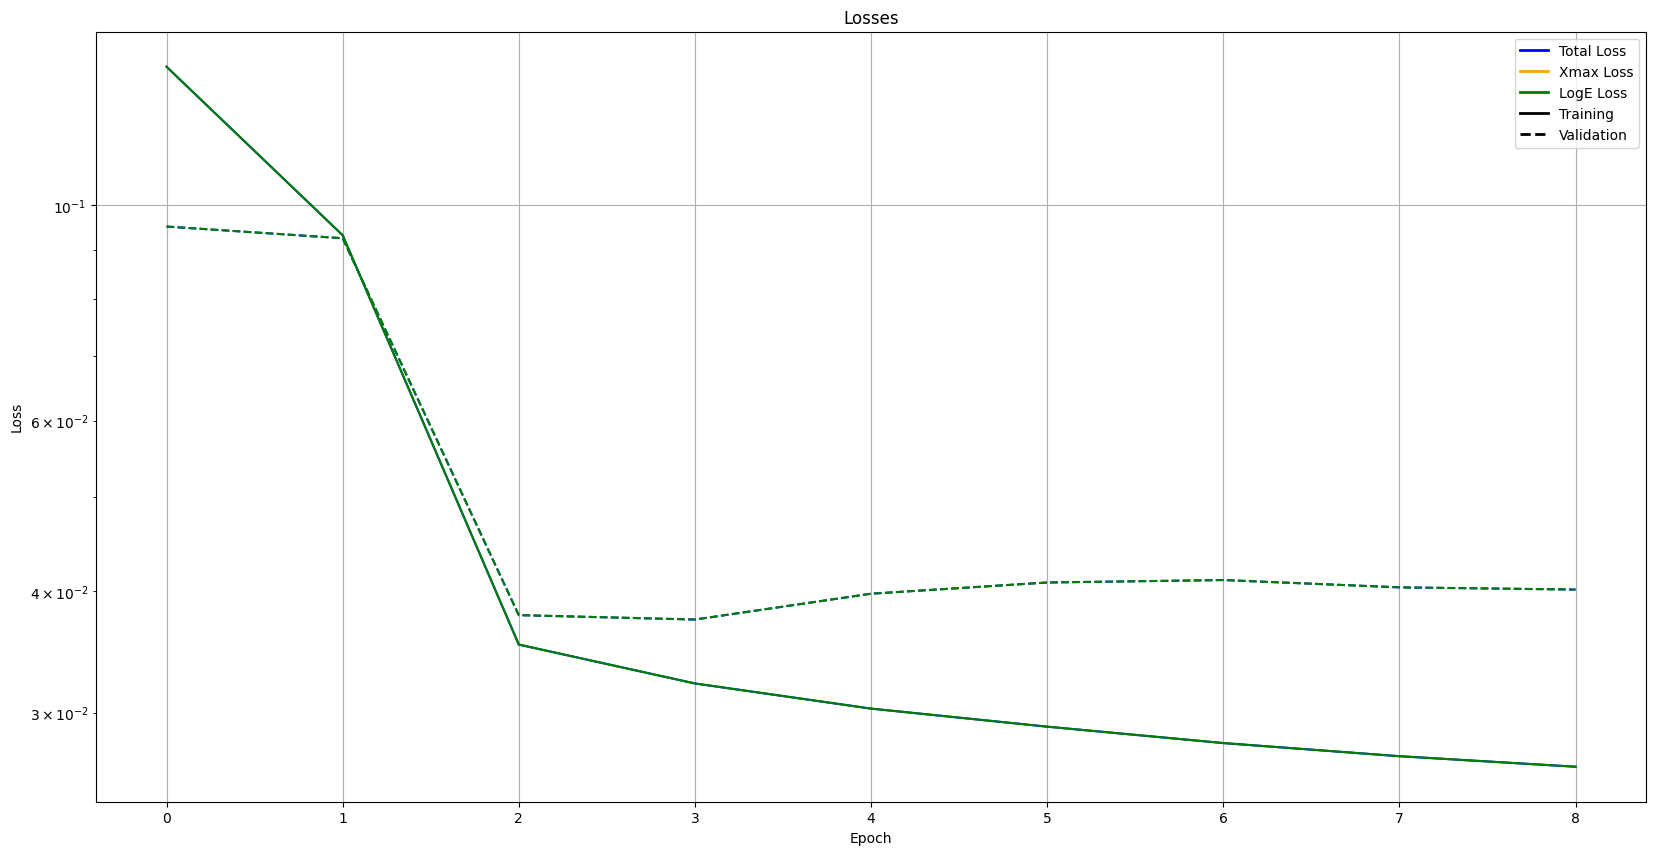

In [56]:
# Loss Plot
EpochLosses    = tracker.EpochLoss
EpochValLosses = tracker.EpochValLoss
Keys = list(EpochLosses.keys())
Nepochs = len(EpochLosses[Keys[0]])

ax = plt.figure(figsize=(20, 10)).gca()

# Define colors
colors = ['blue', 'orange', 'green', 'red','cyan','purple','magenta','yellow']

skip_keys = ['Rp','T0','Chi_0','Total']
skip_keys = []

custom_lines = []
custom_keys  = []
for i in range(len(Keys)):
    if Keys[i] in skip_keys: continue
    plt.plot(EpochLosses[Keys[i]]   , color=colors[i], label=Keys[i] + ' - Training')
    plt.plot(EpochValLosses[Keys[i]], color=colors[i], label=Keys[i] + ' - Validation', linestyle='dashed')
    custom_lines.append(Line2D([0], [0], color=colors[i], lw=2))
    custom_keys.append(Keys[i]+' Loss')

custom_lines+= [Line2D([0], [0], color='black', lw=2),
                Line2D([0], [0], color='black', lw=2, linestyle='dashed')]
custom_keys += ['Training', 'Validation']


ax.legend(custom_lines, custom_keys)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True)) # integer ticks
ax.set_title('Losses')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_yscale('log')
ax.grid()

In [57]:
best_state_dict = model.best_state_dict
Final_state_dict = model.state_dict

model.apply(lambda x : best_state_dict)

Model_XmaxEnergy_Conv3d_withRejection(
  (Conv_Activation): LeakyReLU(negative_slope=0.01)
  (Dense_Activation): ReLU()
  (Angle_Activation): Tanh()
  (Conv_Dropout): Dropout3d(p=0.2, inplace=False)
  (Dense_Dropout): Dropout(p=0.2, inplace=False)
  (Rejection_Activation): Sigmoid()
  (conv0): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 0))
  (Conv1): Conv_Skip_Block_3d(
    (conv1): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (conv2): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (activation_function): LeakyReLU(negative_slope=0.01)
    (dropout): Dropout3d(p=0.2, inplace=False)
  )
  (Conv2): Conv_Skip_Block_3d(
    (conv1): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (conv2): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (activation_function): LeakyReLU(negative_slope=0.01)
    (dropout): Dropout3d(p=0.2, inplace=False)
  )

In [58]:
# Define some metrics
def MeanSquaredError(Truths,Predictions):
    return ((Truths-Predictions)**2).mean()
def MeanAbsoluteError(Truths,Predictions):
    return (np.abs(Truths-Predictions)).mean() if type(Truths) != torch.Tensor else (torch.abs(Truths-Predictions)).mean()
def Percentile68(Truths,Predictions):
    return np.percentile(np.abs(Truths-Predictions),68) if type(Truths) != torch.Tensor else torch.quantile(torch.abs(Truths-Predictions),0.68)

In [59]:
# Compute the Test Set
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = torch.device('cpu')
model.to(device)
torch.cuda.empty_cache()

Dataset.State      = 'Static'
# Dataset.BatchSize  = len(Dataset)//256
Dataset.BatchSize  = 64
Dataset.RandomIter = False
Truth = []
Pred  = []
Rec   = []
Gate  = []
gated = None
model.eval()
EvI = 0
with torch.no_grad():
    for EventIndex, BatchMains, BatchAux, BatchTruth, BatchRec in Dataset:
        
        model_out = model(BatchMains, BatchAux)

        if gated is None:
            if isinstance(model_out, dict):
                if 'Rejection' in model_out:
                    gated = True
                else:
                    raise NotImplementedError(f"Found Model Out Dict, without Rejection, not implemented")
            else:
                gated = False

        Truth.append(BatchTruth)
        Rec  .append(BatchRec)

        if not gated:
            Pred.append(model_out.cpu())
        else:
            Pred.append(model_out['Pred']     .cpu())
            Gate.append(model_out['Rejection'].cpu())

        EvI += 1
print()
Truth = torch.cat(Truth, dim=0)
Pred  = torch.cat(Pred , dim=0)
Rec   = torch.cat(Rec  , dim=0)
if gated:
    Gate = torch.cat(Gate, dim=0)

print(f'Pred Loss {MeanSquaredError(Truth,Pred)}')
print(f'Rec  Loss {MeanSquaredError(Truth,Rec )}')

Truth = Dataset.Unnormalise_Truth(Truth)
Pred  = Dataset.Unnormalise_Truth(Pred)
Rec   = Dataset.Unnormalise_Truth(Rec)

# drop NaN values
if True:
    # Looking for nans, sum up all of 2nd dim
    WeirdSum = Truth.sum(dim=1) + Pred.sum(dim=1) + Rec.sum(dim=1)
    Mask = ~torch.isnan(WeirdSum)
    print(f'Dropping {len(Truth) - Mask.sum()} NaN values')
    Truth = Truth[Mask]
    Pred  = Pred [Mask]
    Rec   = Rec  [Mask]
    if gated:
        Gate = Gate[Mask]
    NanLocs = torch.where(Mask==0)
    print(f' Nan Locations {NanLocs}')


Truth = Truth.numpy()
Pred  = Pred .numpy()
Rec   = Rec  .numpy()
if gated:
    Gate = Gate.numpy()


print(Truth.shape)
print(Pred.shape)
if gated:
    print(Gate.shape)


Pred Loss 0.8688562512397766
Rec  Loss inf
Dropping 0 NaN values
 Nan Locations (tensor([], dtype=torch.int64),)
(375911, 2)
(375911, 2)
(375911, 2)


In [64]:
# Compute Metric
TruthKeys  = Dataset.Truth_Keys
TruthUnits = Dataset.Truth_Units

Pred68 = []
Rec68  = []

if "SDPTheta_c" in TruthKeys and "SDPPhi_c" in TruthKeys:
    # The Unnormalise_Truth will return SDPTheta and SDPPhi values, not c/s of either
    TruthKeys  = ['SDPTheta','SDPPhi']
    TruthUnits = ['rad','rad']  # Default Units for SDPTheta and SDPPhi

    


for i in range(len(TruthKeys)):
    if TruthUnits[i] == 'rad': 
        AngDivPred = np.arctan2(np.sin(Truth[:,i]-Pred[:,i]),np.cos(Truth[:,i]-Pred[:,i]))
        AngDivRec  = np.arctan2(np.sin(Truth[:,i]-Rec[:,i] ),np.cos(Truth[:,i]-Rec[:,i] ))
        Pred68.append(np.percentile(np.abs(AngDivPred),68))
        Rec68 .append(np.percentile(np.abs(AngDivRec ),68))
    elif TruthUnits[i] == 'deg':
        AngDivPred = np.arctan2(np.sin(np.deg2rad(Truth[:,i]-Pred[:,i])),np.cos(np.deg2rad(Truth[:,i]-Pred[:,i])))
        AngDivRec  = np.arctan2(np.sin(np.deg2rad(Truth[:,i]-Rec[:,i] )),np.cos(np.deg2rad(Truth[:,i]-Rec[:,i] )))
        Pred68.append(np.rad2deg(np.percentile(np.abs(AngDivPred),68)))
        Rec68 .append(np.rad2deg(np.percentile(np.abs(AngDivRec ),68)))
    else:
        Pred68.append(np.percentile(np.abs(Truth[:,i]-Pred[:,i]),68))
        Rec68 .append(np.percentile(np.abs(Truth[:,i]-Rec [:,i]),68))

# Print Out the values
    
for i in range(len(TruthKeys)):
    if TruthUnits[i] == 'rad': # Convert to degrees
        print(f'Adjusted Percentile for Pred {(TruthKeys[i]+"                          ")[:10]} {Pred68[i]*180/np.pi:.5} deg')
        print(f'Adjusted Percentile for Rec  {(TruthKeys[i]+"                          ")[:10]} {Rec68[i] *180/np.pi:.5} deg')
        print(f'Percentile Ratio   Pred/Rec             {Pred68[i]/Rec68[i]:.5}')
        print()
    else:
        print(f'Adjusted Percentile for Pred {(TruthKeys[i]+"                          ")[:10]} {Pred68[i]:.5} {TruthUnits[i]}')
        print(f'Adjusted Percentile for Rec  {(TruthKeys[i]+"                          ")[:10]} {Rec68[i] :.5} {TruthUnits[i]}')
        print(f'Percentile Ratio   Pred/Rec             {Pred68[i]/Rec68[i]:.5}')
        print()

Adjusted Percentile for Pred Xmax       67.724 g/cm^2
Adjusted Percentile for Rec  Xmax       263.54 g/cm^2
Percentile Ratio   Pred/Rec             0.25698

Adjusted Percentile for Pred LogE       0.23546 
Adjusted Percentile for Rec  LogE       0.4254 
Percentile Ratio   Pred/Rec             0.55351



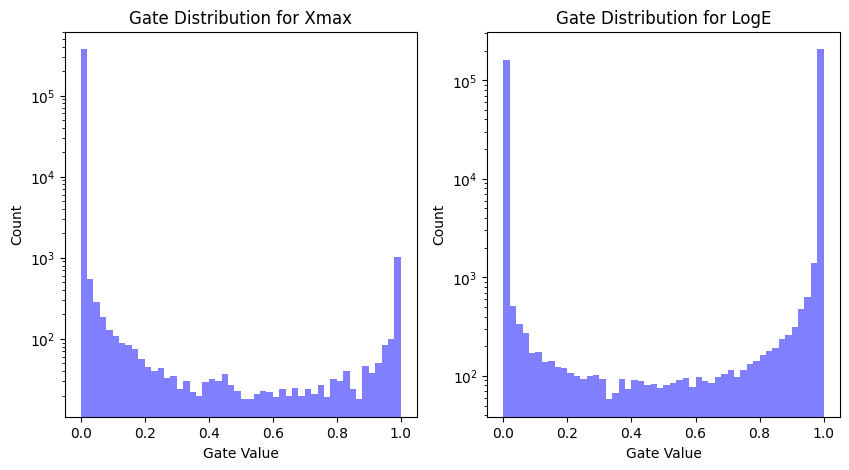

In [65]:
# Gating Distribution
TruthKeys = Dataset.Truth_Keys


fig, axs = plt.subplots(1,len(TruthKeys),figsize = (5*len(TruthKeys),5))
for i,key in enumerate(TruthKeys):
    ax = axs[i]

    ax.hist(Gate[:,i], bins=50, alpha=0.5, label='Gate', color='blue')
    ax.set_title(f'Gate Distribution for {key}')
    ax.set_xlabel('Gate Value')
    ax.set_ylabel('Count')
    ax.set_yscale('log')    


In [66]:
from matplotlib.colors import LinearSegmentedColormap

# Create a truncated version of the inferno colormap (first 90%)
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = LinearSegmentedColormap.from_list(
        f'truncated_{cmap.name}', 
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

# Original inferno colormap
inferno = plt.get_cmap('inferno_r')

# Truncated colormap: first 90%
truncated_inferno = truncate_colormap(inferno, 0.05, 1)


Total Points before cuts 375911
Xmax Total Points after cuts 234007
LogE Total Points after cuts 255756


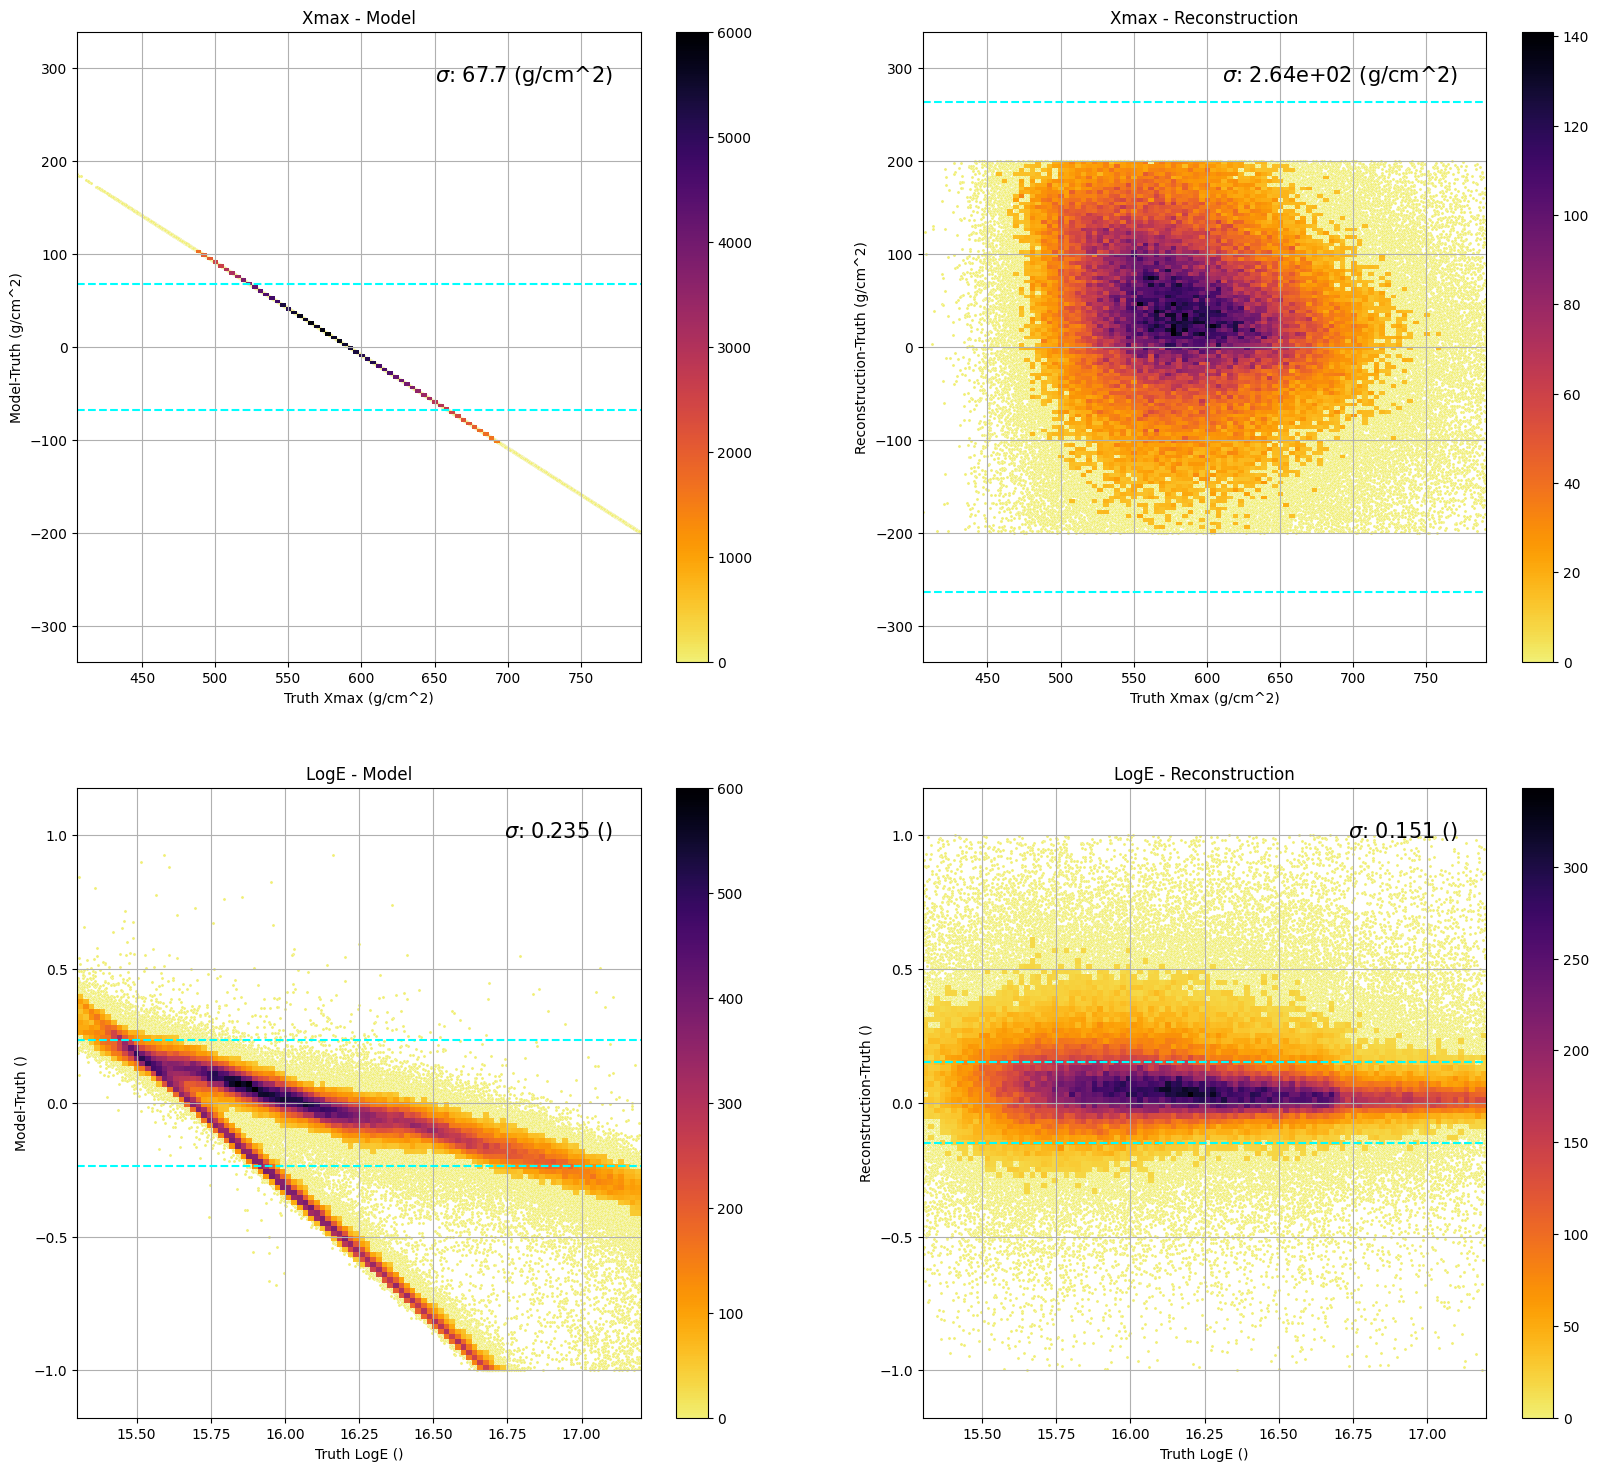

In [67]:
def CombinedDeviationPlots(TruthKeys,TruthUnits,Truth,Pred,Rec,skip_cut = False):
    plt.style.use('default')
    fig, ax = plt.subplots(len(TruthKeys),2, figsize=(20,9*len(TruthKeys)))
    print(f'Total Points before cuts {len(Truth)}')
    for i in range(len(TruthKeys)):
        X  = Truth[:, i] if TruthUnits[i] != 'rad' else Truth[:, i]/np.pi*180
        Yp = Pred[:, i] - Truth[:, i] if TruthUnits[i] != 'rad' else (Pred[:, i] - Truth[:, i])/np.pi*180
        Yr = Rec [:, i] - Truth[:, i] if TruthUnits[i] != 'rad' else (Rec [:, i] - Truth[:, i])/np.pi*180
        
        # Scaling Cuts
        if skip_cut: cut = (np.abs(Yp)>0)
        elif TruthKeys[i] == 'SDPTheta': cut = (np.abs(Yp)>0) #  (np.abs(Yp)<20)    & (np.abs(Yr)<20)
        elif TruthKeys[i] == 'SDPPhi'  : cut = (np.abs(Yp)>0) #  (np.abs(Yp)<20)    & (np.abs(Yr)<20) #   & (np.abs(X)<50)
        elif TruthKeys[i] == 'Chi0'    : cut = (np.abs(Yp)<20)    & (np.abs(Yr)<20)
        elif TruthKeys[i] == 'Rp'      : cut = (np.abs(Yp)<5000)  & (np.abs(Yr)<5000)
        elif TruthKeys[i] == 'CEDist'  : cut = (np.abs(Yp)<5000)  & (np.abs(Yr)<5000)
        elif TruthKeys[i] == 'T0'      : cut = (np.abs(Yp)<10000) & (np.abs(Yr)<10000)
        elif TruthKeys[i] == 'Xmax'    : cut = (np.abs(Yp)<200)   & (np.abs(Yr)<200)  & (X>100)
        elif TruthKeys[i] == 'LogE'    : cut = (X>0)              & (np.abs(Yp)<1)    & (np.abs(Yr)<1)
        elif TruthKeys[i] == 'z'       : cut = (X>0.4) 
        else: cut = (np.abs(Yp)>0)

        # 68th Percentile - Calculate Before the cuts, 
        Percentile68_p = np.percentile(np.abs(Yp[np.isfinite(Yp)]),68)
        Percentile68_r = np.percentile(np.abs(Yr[np.isfinite(Yr)]),68)

        X = X[cut]
        Yp = Yp[cut]
        Yr = Yr[cut]

        # Secondary Y_lim cuts for scaling
        # Yp_STD = np.percentile(np.abs(Yp),68)
        # cut = (np.abs(Yp)<5*Yp_STD) & (np.abs(Yr)<5*Yp_STD)
        # X  = X [cut]
        # Yp = Yp[cut]
        # Yr = Yr[cut]
        print(f'{TruthKeys[i]} Total Points after cuts {len(X)}')
        # sns.scatterplot(x=X, y=Yp, ax=ax[i,0], s=5,color='orange')
        # sns.scatterplot(x=X, y=Yr, ax=ax[i,1], s=5,color='orange')

        sns.scatterplot(x=X, y=Yp, ax=ax[i,0], s=5,color=truncated_inferno(0))
        sns.scatterplot(x=X, y=Yr, ax=ax[i,1], s=5,color=truncated_inferno(0))


        sns.histplot(x=X, y=Yp, ax=ax[i,0], bins=100, pthresh=0.1,cmap = truncated_inferno,cbar = True)
        sns.histplot(x=X, y=Yr, ax=ax[i,1], bins=100, pthresh=0.1,cmap = truncated_inferno,cbar = True)
        if TruthUnits[i] != 'rad': 
            ax[i,0].set_ylabel(f'Model-Truth ({TruthUnits[i]})')
            ax[i,0].set_xlabel(f'Truth {TruthKeys[i]} ({TruthUnits[i]})')

            ax[i,1].set_ylabel(f'Reconstruction-Truth ({TruthUnits[i]})')
            ax[i,1].set_xlabel(f'Truth {TruthKeys[i]} ({TruthUnits[i]})')

            
        else:                      
            ax[i,0].set_ylabel(f'Model-Truth (degrees)')
            ax[i,0].set_xlabel(f'Truth {TruthKeys[i]} (degrees)')

            ax[i,1].set_ylabel(f'Reconstruction-Truth (degrees)')
            ax[i,1].set_xlabel(f'Truth {TruthKeys[i]} (degrees)')
        
        ax[i,0].set_title(f'{TruthKeys[i]} - Model')
        ax[i,1].set_title(f'{TruthKeys[i]} - Reconstruction')

        ax[i,0].set_xlim(min(X),max(X))
        ax[i,1].set_xlim(min(X),max(X))

        ax[i,0].grid()
        ax[i,1].grid()

        # ax[0,1].set_facecolor('lightgrey')
        # ax[1,1].set_facecolor('lightgrey')


        
        ax[i,0].set_ylim(-Percentile68_p*5,Percentile68_p*5)
        ax[i,1].set_ylim(-Percentile68_p*5,Percentile68_p*5)



        # Add as a texbox to top right of plot
        if TruthUnits[i]!= 'rad':
            ax[i,0].text(0.95, 0.95, f'$\\sigma$: {Percentile68_p:.3} ({TruthUnits[i]})', verticalalignment='top', horizontalalignment='right', transform=ax[i,0].transAxes, fontsize=15)
            ax[i,1].text(0.95, 0.95, f'$\\sigma$: {Percentile68_r:.3} ({TruthUnits[i]})', verticalalignment='top', horizontalalignment='right', transform=ax[i,1].transAxes, fontsize=15)

        else:
            ax[i,0].text(0.95, 0.95, f'$\\sigma$: {Percentile68_p:.3} (deg)', verticalalignment='top', horizontalalignment='right', transform=ax[i,0].transAxes, fontsize=15)
            ax[i,1].text(0.95, 0.95, f'$\\sigma$: {Percentile68_r:.3} (deg)', verticalalignment='top', horizontalalignment='right', transform=ax[i,1].transAxes, fontsize=15)



        ax[i,0].axhline(Percentile68_p, color='cyan', linestyle='--')
        ax[i,0].axhline(-Percentile68_p, color='cyan', linestyle='--')

        ax[i,1].axhline(Percentile68_r, color='cyan', linestyle='--')
        ax[i,1].axhline(-Percentile68_r, color='cyan', linestyle='--')
        
    return fig
    
figure = CombinedDeviationPlots(TruthKeys,TruthUnits,Truth,Pred,Rec,skip_cut=False)
# figure.savefig(f'../Results/{Model_Name}_Combined_Deviation.png')

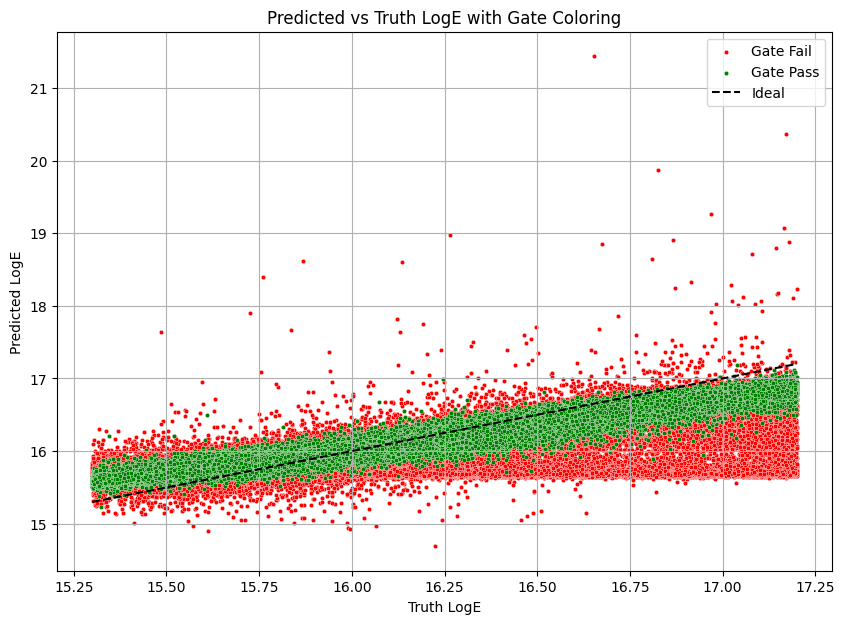

In [68]:
# Scatter The log E pred vs the truth, using Gate at 0.5 split

Gate_CutVal = 0.5

if 'LogE' in TruthKeys:
    i = TruthKeys.index('LogE')
    X = Truth[:, i]
    Yp = Pred[:, i]
    Yr = Rec [:, i]
    if gated:
        G = Gate[:, i]
        pass_cut = G>Gate_CutVal
        fail_cut = G<=Gate_CutVal

        plt.figure(figsize=(10,7))
        sns.scatterplot(x=X[fail_cut], y=Yp[fail_cut], color='red', label='Gate Fail', s=10)
        sns.scatterplot(x=X[pass_cut], y=Yp[pass_cut], color='green', label='Gate Pass', s=10)
        plt.plot([min(X), max(X)], [min(X), max(X)], 'k--', label='Ideal')
        plt.xlabel('Truth LogE')
        plt.ylabel('Predicted LogE')
        plt.title('Predicted vs Truth LogE with Gate Coloring')
        plt.legend()
        plt.grid()

Total Points before cuts 211934
Xmax Total Points after cuts 146514
LogE Total Points after cuts 169598


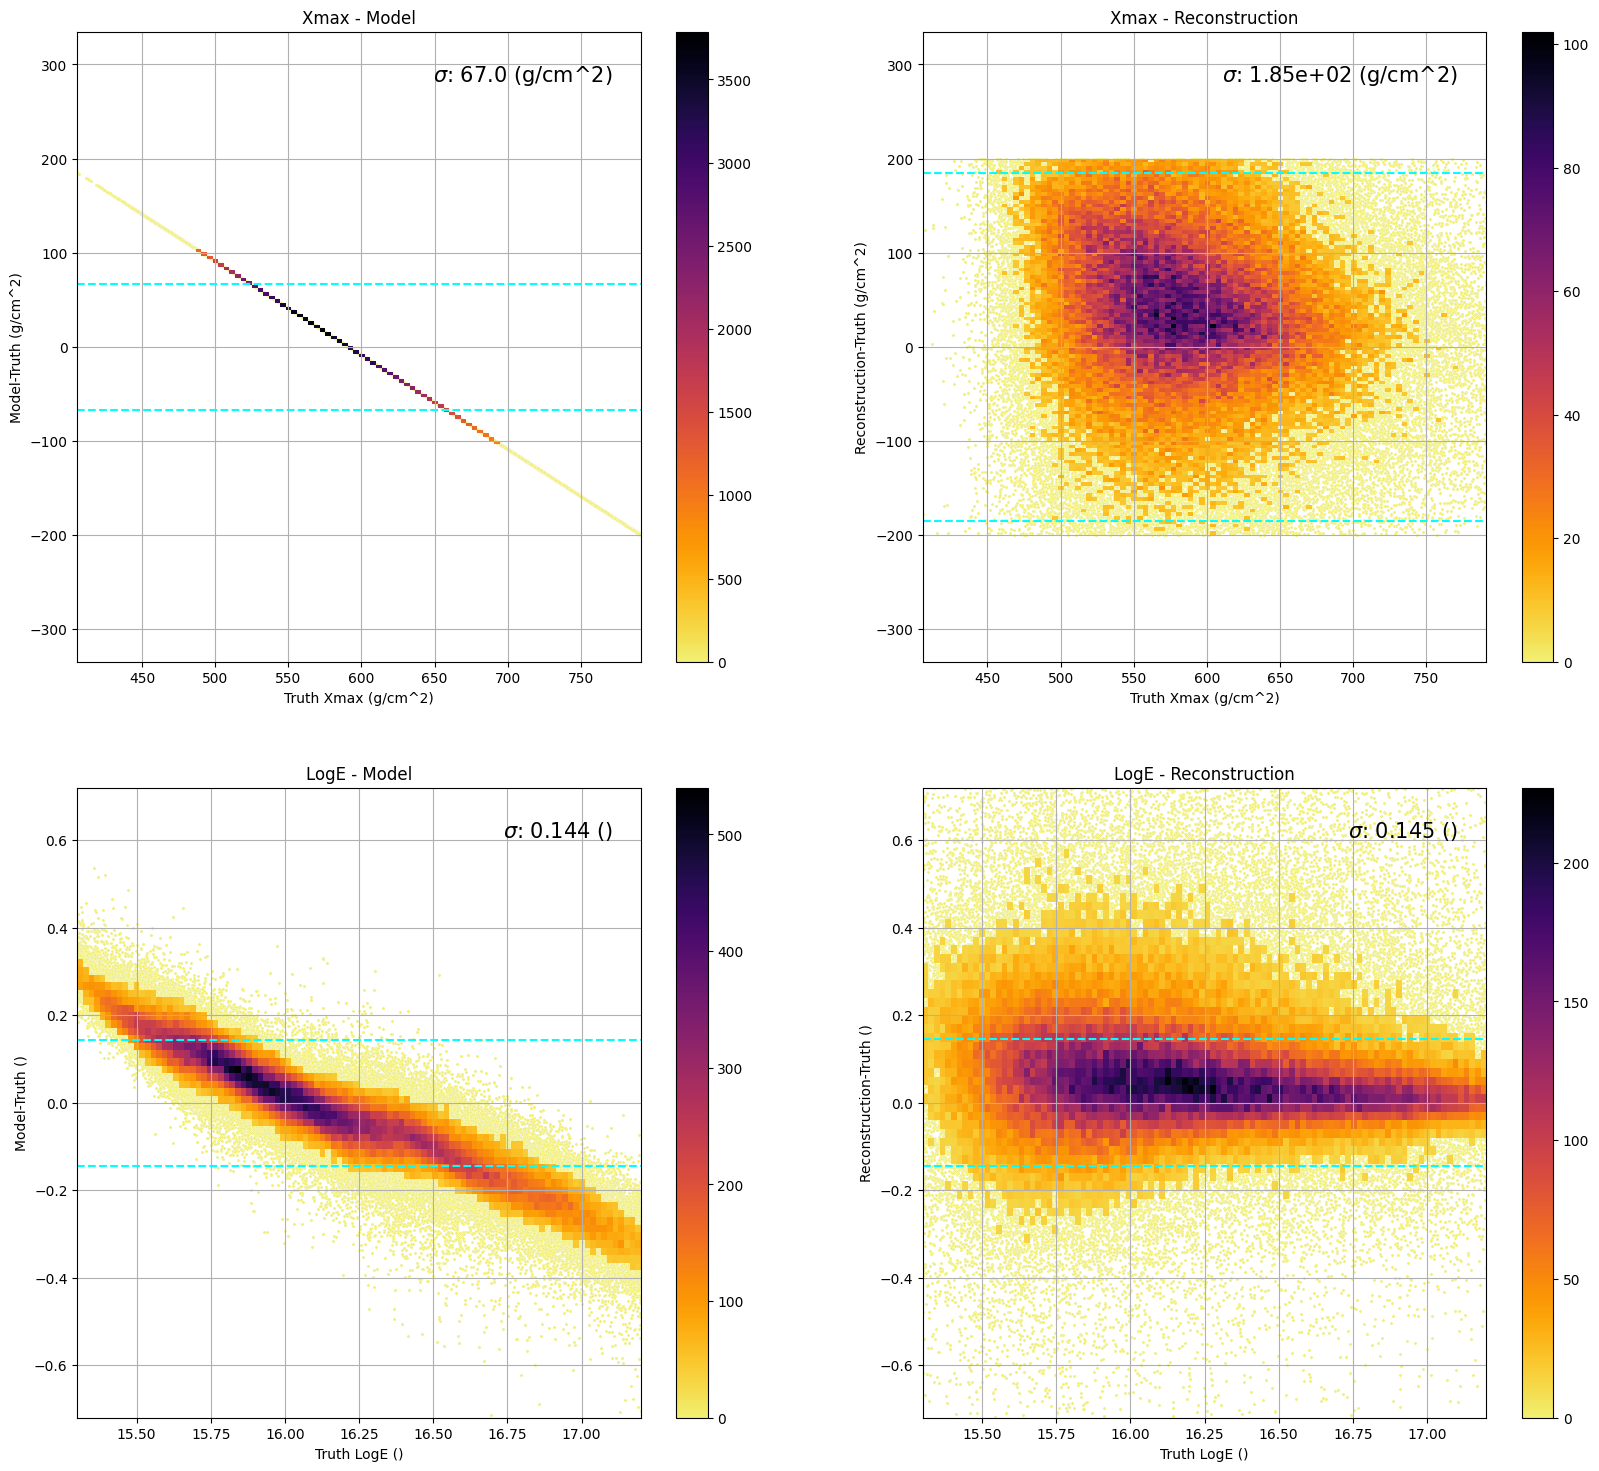

In [69]:
Gate_CutVal = 0.5
Mask = (Gate[:,Dataset.Truth_Keys.index('LogE')]>Gate_CutVal) if gated else np.ones(len(Truth), dtype=bool)
figure = CombinedDeviationPlots(TruthKeys,TruthUnits,Truth[Mask],Pred[Mask],Rec[Mask],skip_cut=False)

# Gobtain a list of events with closed Gating, see whats up with the ting

In [70]:
Gate_CutVal = 0.1
All_Gates_Fails = (Gate[:,Dataset.Truth_Keys.index('LogE')]<Gate_CutVal) 
All_Ids = Dataset._EventIds

All_Fail_Ids = []

for i in range(len(All_Gates_Fails)):
    if All_Gates_Fails[i]: All_Fail_Ids.append(All_Ids[i])
print(f'Total Events: {len(All_Fail_Ids)} / {len(All_Ids)}')


Total Events: 161975 / 375911


In [73]:
for i, id in enumerate(All_Fail_Ids):
    print(str(id).zfill(8))
    if i == 10:
        break

17880467
12120864
03192216
03192356
13642407
13648995
12927968
12928632
05001872
05008048
05009232


In [74]:
# Dump CSV File for events
import csv

with open('fail_ids_from_rej.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['id'])  # header
    for i, id in enumerate(All_Fail_Ids):
        writer.writerow([int(id)])  # no zero padding

# Remove the spoofed Data

In [22]:
Active_Indices = Dataset.ActiveIndeces
Aux_Keys = Dataset.Aux_Keys
print(f'Aux Keys: {Aux_Keys}')
Spoofing_Index = Aux_Keys.index('Spoofing')
print(f'Spoofing Index: {Spoofing_Index}')
# Spoofed_Energy_Mask = Dataset.

Spoofing = Dataset._Aux[Active_Indices,Spoofing_Index].numpy()
Spoofing_Mask = (Spoofing == 0)
print(f' Spoofing Mask Shape: {Spoofing_Mask.shape} ')

Gate_CutVal = 0.5
Gate_Mask = (Gate[:,Dataset.Truth_Keys.index('LogE')]>Gate_CutVal) if gated else np.ones(len(Truth), dtype=bool)

Spoofing_Gate_Mask = Gate_Mask & Spoofing_Mask


figure = CombinedDeviationPlots(TruthKeys,TruthUnits,Truth[Spoofing_Gate_Mask],Pred[Spoofing_Gate_Mask],Rec[Spoofing_Gate_Mask],skip_cut=False)


Aux Keys: ('Event_Class', 'Primary', 'LogE', 'CosZenith', 'Xmax', 'Chi0', 'Rp', 'AngularVelocity')


ValueError: tuple.index(x): x not in tuple

# Check the relationship between the model Gate and Reco Pass/Fail

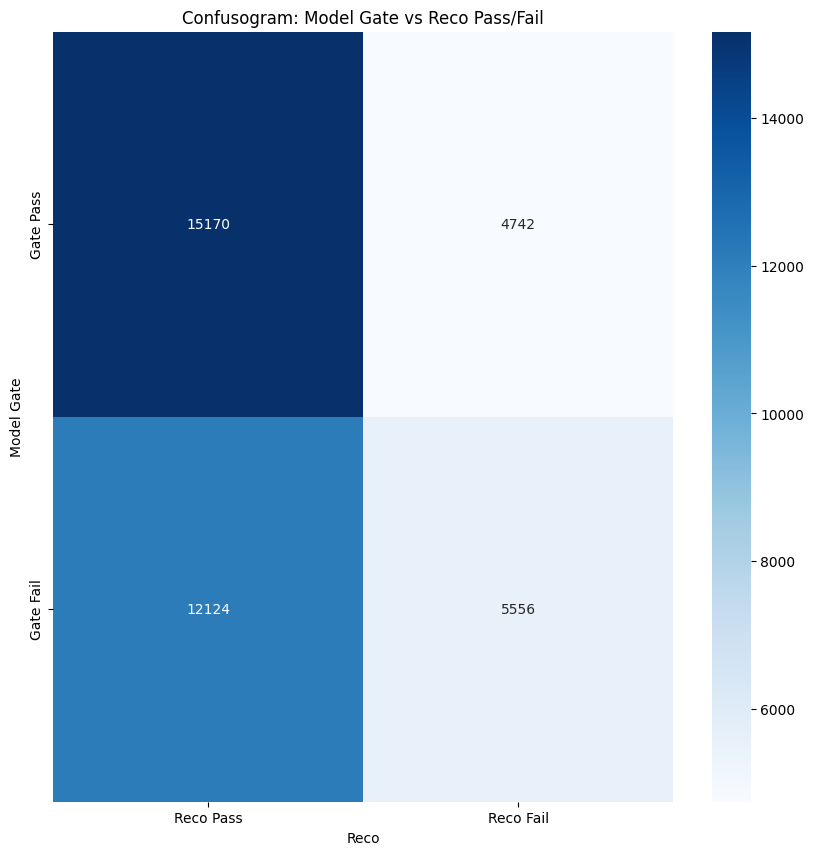

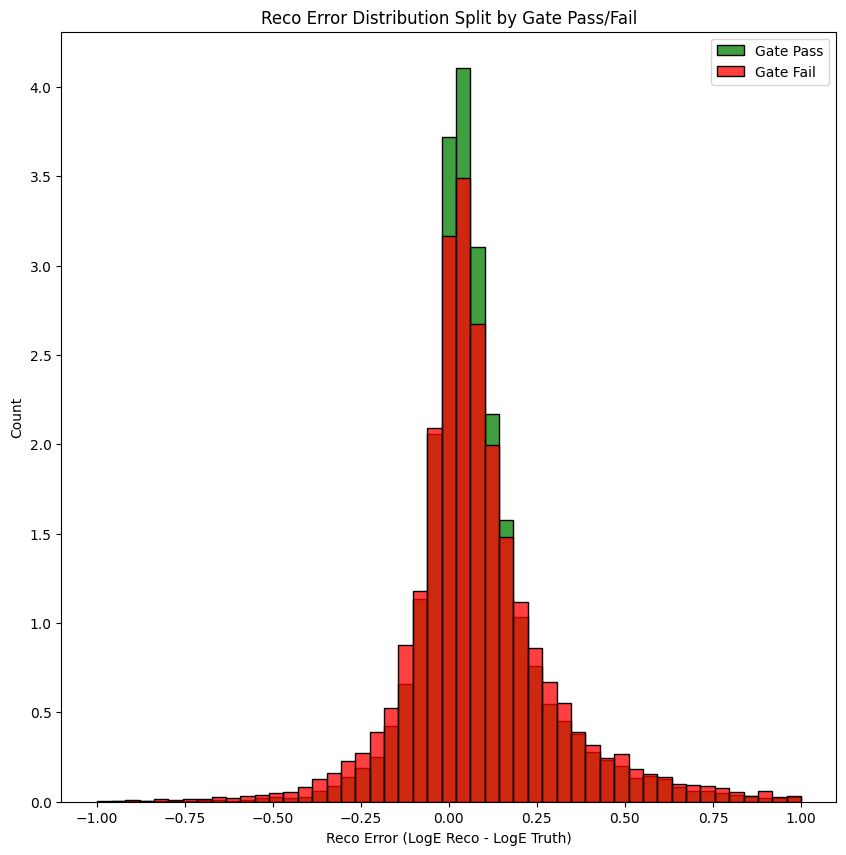

In [25]:
# First histogram of the Reco Error split by the Gate values
RecError = Rec[:,Dataset.Truth_Keys.index('LogE')] - Truth[:,Dataset.Truth_Keys.index('LogE')]

RecoPass = np.isfinite(RecError) 
GatePass = Mask


# Confusion matrix: rows=Gate (Pass/Fail), cols=Reco (Pass/Fail)
conf_matrix = np.zeros((2, 2), dtype=int)
conf_matrix[0, 0] = np.sum(GatePass & RecoPass)      # Gate Pass, Reco Pass
conf_matrix[0, 1] = np.sum(GatePass & ~RecoPass)     # Gate Pass, Reco Fail
conf_matrix[1, 0] = np.sum(~GatePass & RecoPass)     # Gate Fail, Reco Pass
conf_matrix[1, 1] = np.sum(~GatePass & ~RecoPass)    # Gate Fail, Reco Fail

plt.figure(figsize=(10, 10))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Reco Pass', 'Reco Fail'],
    yticklabels=['Gate Pass', 'Gate Fail']
)
plt.xlabel('Reco')
plt.ylabel('Model Gate')
plt.title('Confusogram: Model Gate vs Reco Pass/Fail')
plt.show()

plt.figure(figsize=(10, 10))
bins = np.linspace(-1, 1, 50)
sns.histplot(RecError[GatePass], bins=bins, color='green', label='Gate Pass', kde=False,stat='density')
sns.histplot(RecError[~GatePass], bins=bins, color='red', label='Gate Fail', kde=False,stat='density')
plt.xlabel('Reco Error (LogE Reco - LogE Truth)')
plt.ylabel('Count')
plt.title('Reco Error Distribution Split by Gate Pass/Fail')
plt.legend()
plt.show()



# Processing Uncleaned Dataset


In [17]:
# Compute the Test Set
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = torch.device('cpu')
model.to(device)
torch.cuda.empty_cache()

Dataset.State      = 'Test'
# Dataset.BatchSize  = len(Dataset)//256
Dataset.BatchSize  = 64
Dataset.RandomIter = False

Old_Good_Event_Mask = Dataset._Good_Event_Mask
Dataset._Good_Event_Mask = Low_AngVel_Cut_Mask


print('Length of the Unfiltered Dataset:', len(Dataset))
Truth = []
Pred  = []
Rec   = []
model.eval()
EvI = 0
with torch.no_grad():
    for EventIndex,BatchMains, BatchAux,BatchTruth,BatchRec in Dataset:
        # print(f'Event {EvI}/{len(Dataset)}', end='\r')
        # Send to device
        # BatchMains = [Main.to(device) for Main in BatchMains]
        # BatchAux   = BatchAux.to(device)
        # BatchAux[] = Dataset._Aux.mean(dim=0)

        Truth .append(BatchTruth)
        Pred  .append(model(BatchMains, BatchAux).cpu())
        Rec   .append(BatchRec)
        EvI+=1
print()
Truth = torch.cat(Truth, dim=0)
Pred  = torch.cat(Pred , dim=0)
Rec   = torch.cat(Rec  , dim=0)

print(f'Pred Loss {MeanSquaredError(Truth,Pred)}')
print(f'Rec  Loss {MeanSquaredError(Truth,Rec )}')

Truth = Dataset.Unnormalise_Truth(Truth)
Pred  = Dataset.Unnormalise_Truth(Pred)
Rec   = Dataset.Unnormalise_Truth(Rec)

# drop NaN values
if True:
    # Looking for nans, sum up all of 2nd dim
    WeirdSum = Truth.sum(dim=1) + Pred.sum(dim=1) + Rec.sum(dim=1)
    Mask = ~torch.isnan(WeirdSum)
    print(f'Dropping {len(Truth) - Mask.sum()} NaN values')
    Truth = Truth[Mask]
    Pred  = Pred [Mask]
    Rec   = Rec  [Mask]
    NanLocs = torch.where(Mask==0)
    print(f' Nan Locations {NanLocs}')

# Remove Bad events
if False:
    Mask = (torch.abs(Truth[:,0]-Rec[:,0]) < 1) & (torch.abs(Truth[:,1]-Rec[:,1]) < 1000)
    print(f'Dropping {len(Truth) - Mask.sum()} Bad events')
    Truth = Truth[Mask]
    Pred  = Pred [Mask]
    Rec   = Rec  [Mask]


Truth = Truth.numpy()
Pred  = Pred .numpy()
Rec   = Rec  .numpy()


print(Truth.shape)
print(Pred.shape)

# Return the good event mask to its original state
Dataset._Good_Event_Mask = Old_Good_Event_Mask

Length of the Unfiltered Dataset: 37592

Pred Loss 0.8184802532196045
Rec  Loss inf
Dropping 0 NaN values
 Nan Locations (tensor([], dtype=torch.int64),)
(37592, 2)
(37592, 2)


Total Points before cuts 37592
Xmax Total Points after cuts 23114
LogE Total Points after cuts 25944


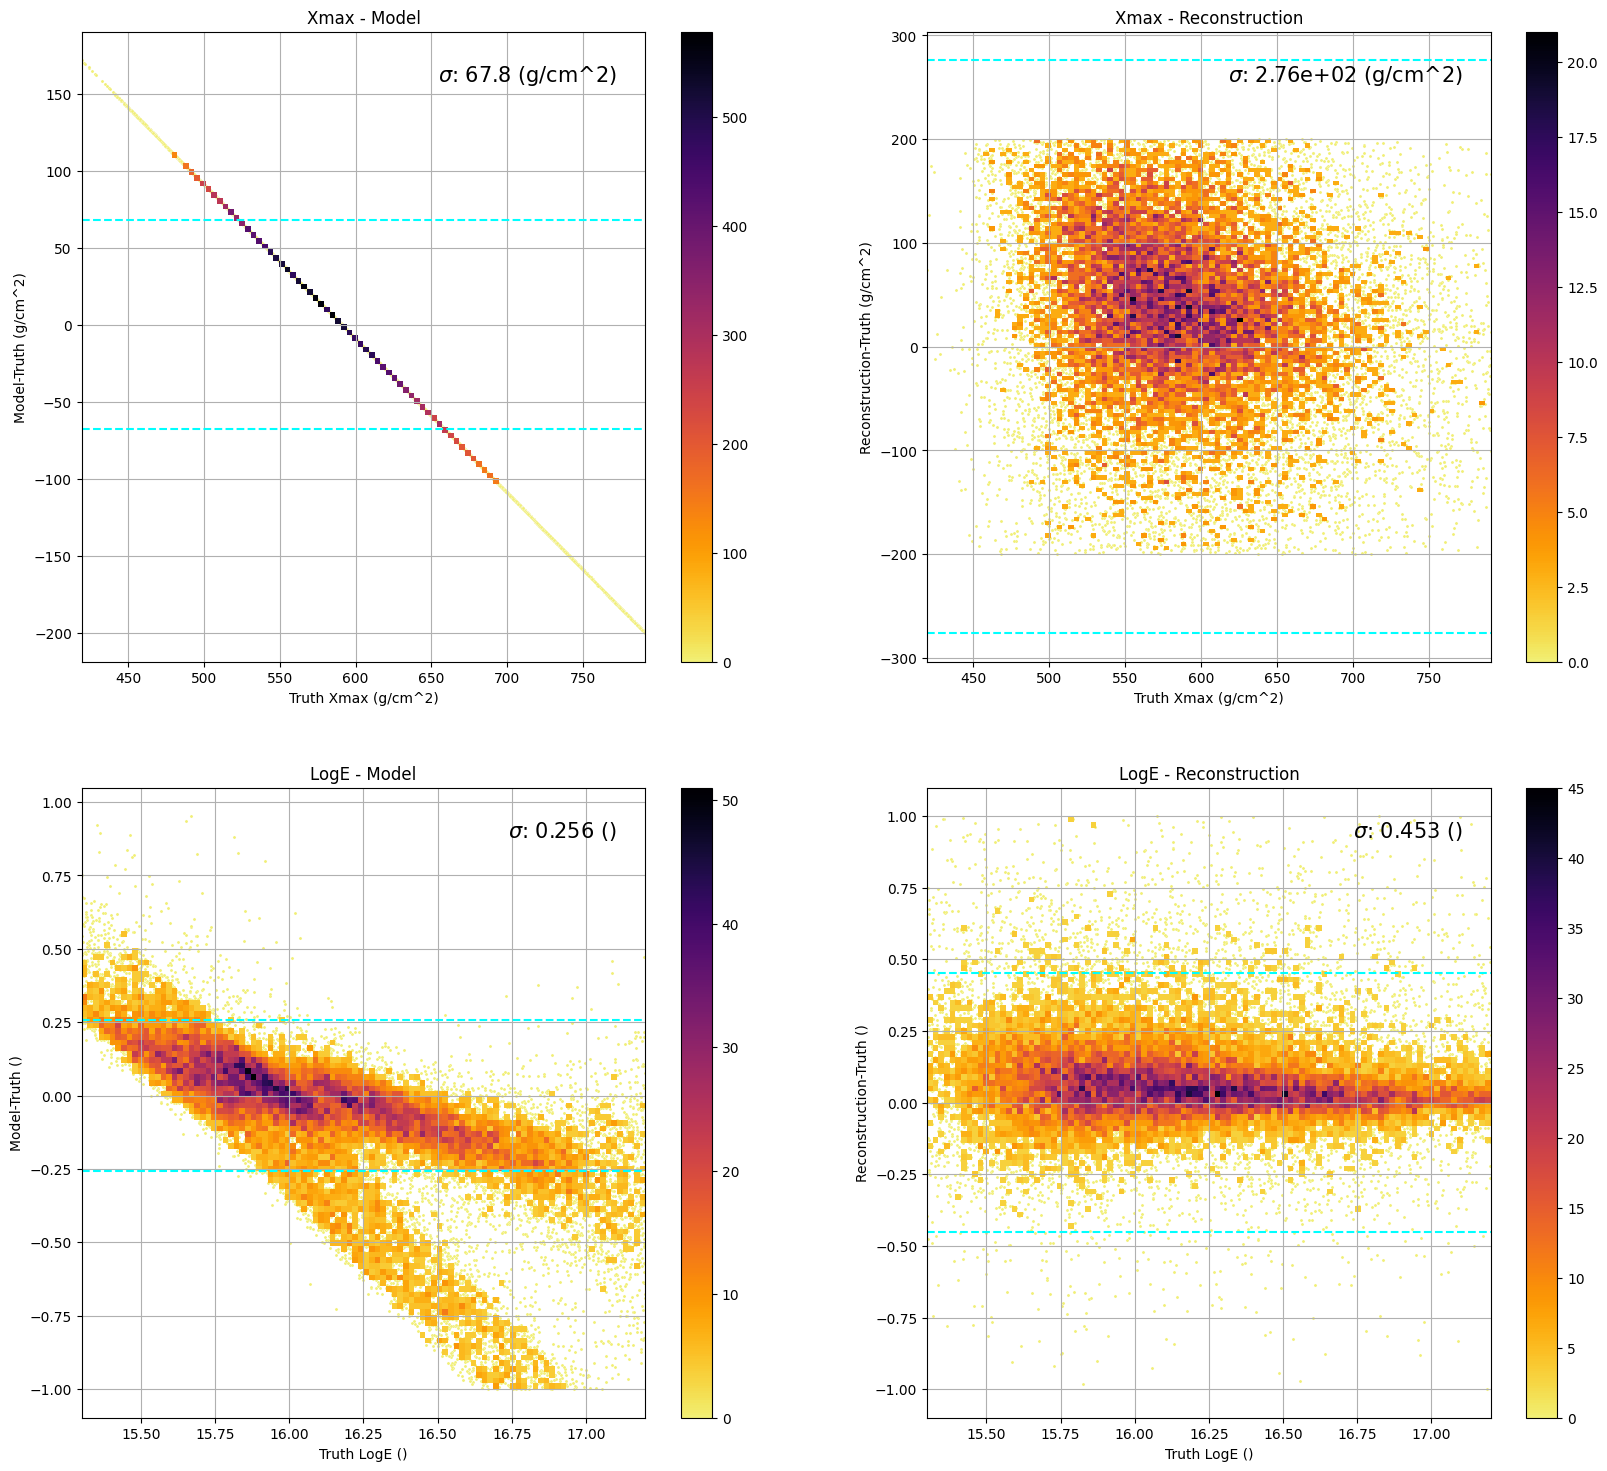

In [19]:
figure = CombinedDeviationPlots(TruthKeys,TruthUnits,Truth,Pred,Rec,skip_cut=False)

Total Points before cuts 37592
Min Rec for Xmax: -196.009033203125 Max Rec: 1584.52001953125
Xmax Total Points after cuts 25871
Doing Skip Cut Log E
Min Rec for LogE: -inf Max Rec: 21.481700897216797
LogE Total Points after cuts 27294


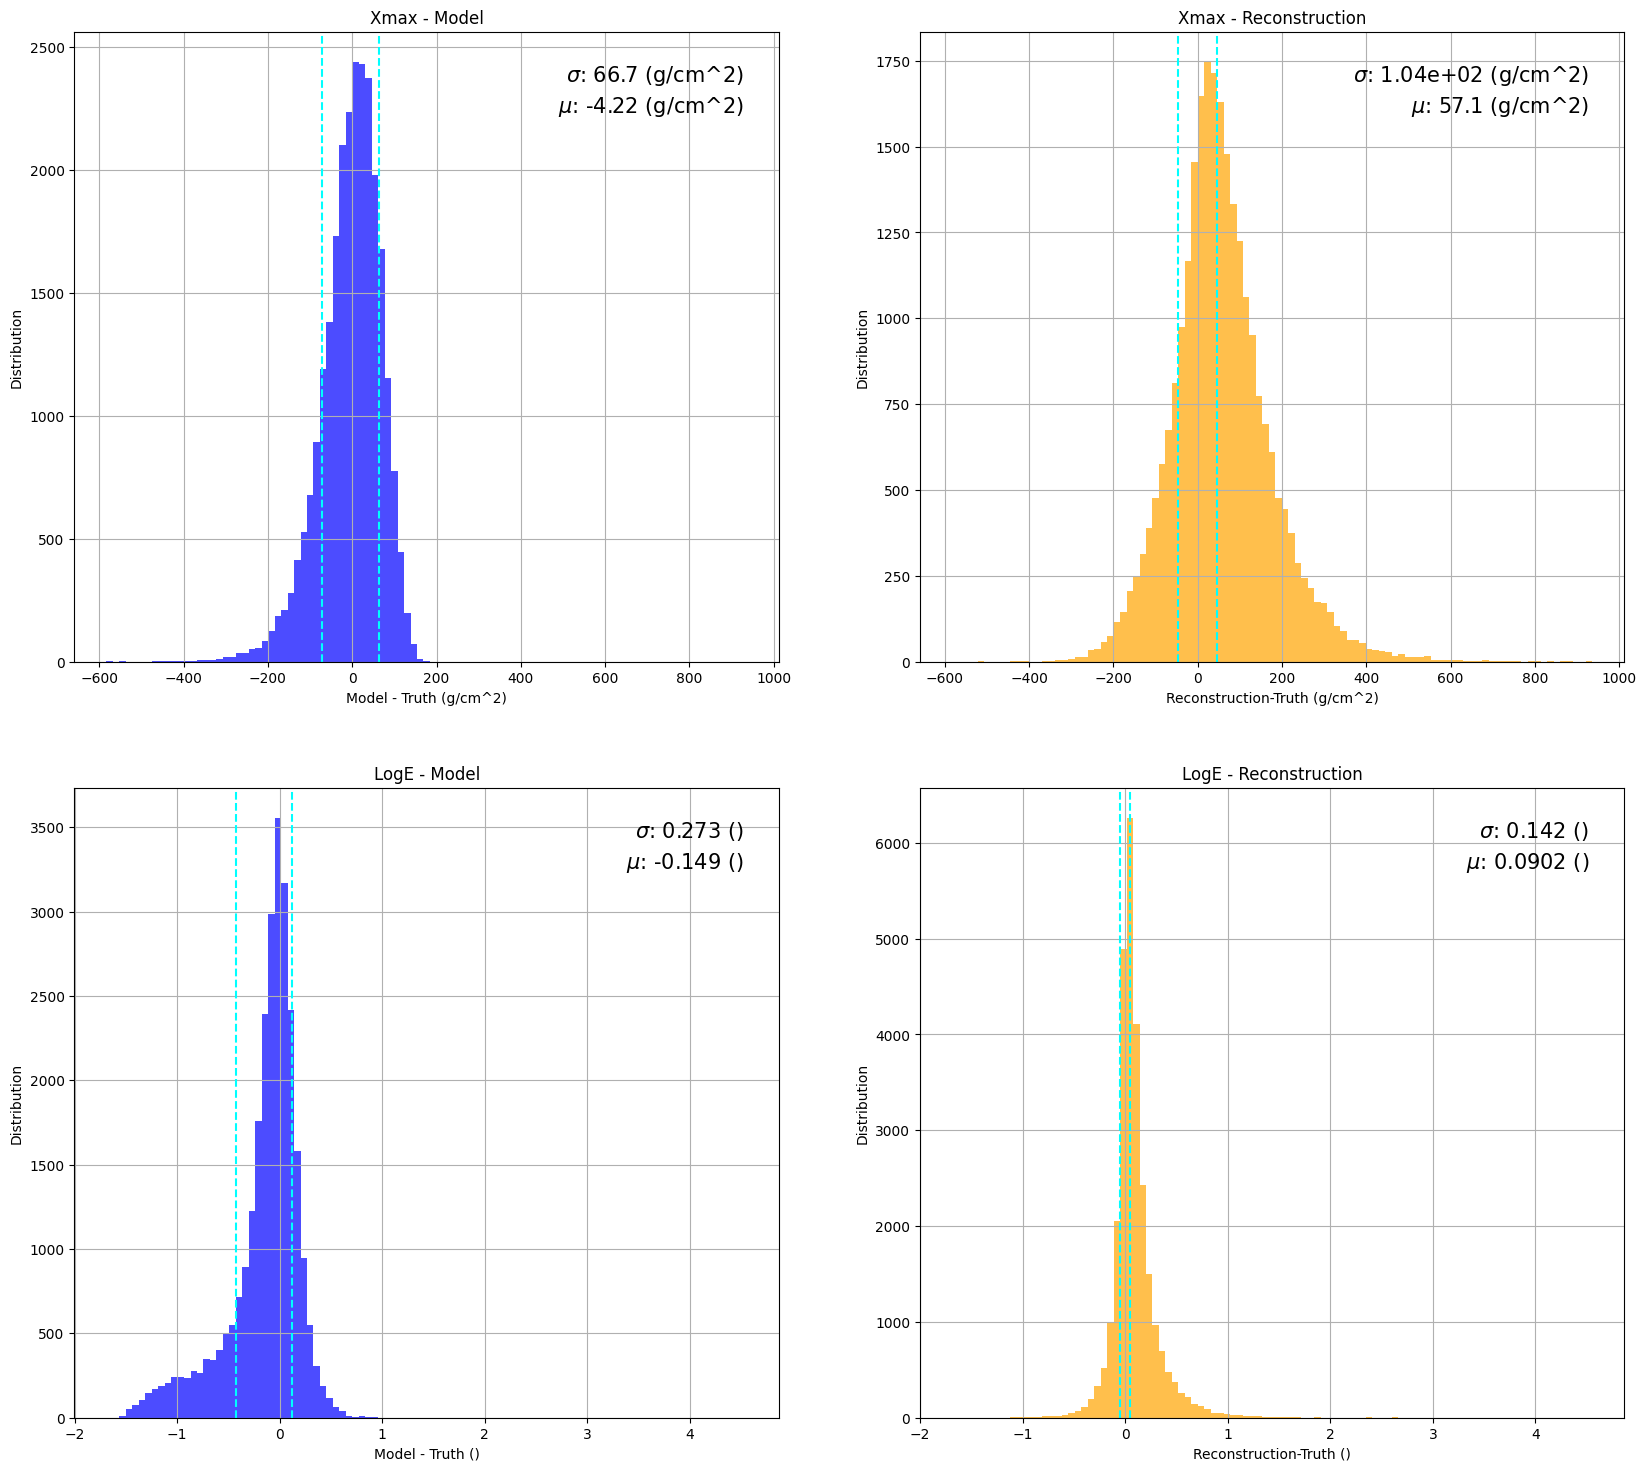

In [33]:
def CombinationHistogramPlots(TruthKeys,TruthUnits,Truth,Pred,Rec,skip_cut=True):
    fig, ax = plt.subplots(len(TruthKeys),2, figsize=(20,9*len(TruthKeys)))
    print(f'Total Points before cuts {len(Truth)}')
    for i in range(len(TruthKeys)):
        X  = Truth[:, i] if TruthUnits[i] != 'rad' else Truth[:, i]/np.pi*180
        Yp = Pred[:, i] - Truth[:, i] if TruthUnits[i] != 'rad' else (Pred[:, i] - Truth[:, i])/np.pi*180
        Yr = Rec [:, i] - Truth[:, i] if TruthUnits[i] != 'rad' else (Rec [:, i] - Truth[:, i])/np.pi*180
        
        # Scaling Cuts
        if skip_cut: 
            if TruthKeys[i] == 'LogE':
                print(f'Doing Skip Cut Log E')
                cut = (X>0) & (np.abs(Yp)<1e6) & (np.abs(Yr)<1e6) # Looser cut for logE, because the errors can be large in log space but not in linear space 
                cut&= np.isfinite(Rec[:, i])
                
            elif TruthKeys[i] == 'Xmax':
                cut = Rec[:, i]>400
            else:
                cut = (np.abs(Yp)>0)
            
        elif TruthKeys[i] == 'SDPTheta': cut = (np.abs(Yp)>0) #  (np.abs(Yp)<20)    & (np.abs(Yr)<20)
        elif TruthKeys[i] == 'SDPPhi'  : cut = (np.abs(Yp)>0) #  (np.abs(Yp)<20)    & (np.abs(Yr)<20) #   & (np.abs(X)<50)
        elif TruthKeys[i] == 'Chi0'    : cut = (np.abs(Yp)<20)    & (np.abs(Yr)<20)
        elif TruthKeys[i] == 'Rp'      : cut = (np.abs(Yp)<5000)  & (np.abs(Yr)<5000)
        elif TruthKeys[i] == 'CEDist'  : cut = (np.abs(Yp)<5000)  & (np.abs(Yr)<5000)
        elif TruthKeys[i] == 'T0'      : cut = (np.abs(Yp)<10000) & (np.abs(Yr)<10000)
        elif TruthKeys[i] == 'Xmax'    : cut = (np.abs(Yp)<200)   & (np.abs(Yr)<200)  & (X>100)
        elif TruthKeys[i] == 'LogE'    : cut = (X>0)              & (np.abs(Yp)<1e6)    & (np.abs(Yr)<1e6) # Looser cut for logE, because the errors can be large in log space but not in linear space
        elif TruthKeys[i] == 'z'       : cut = (X>0.4) 
        else:
            cut = (np.abs(Yp)>0)
                

        print(f'Min Rec for {TruthKeys[i]}: {Rec[:, i].min()} Max Rec: {Rec[:, i].max()}')

        X = X[cut]
        Yp = Yp[cut]
        Yr = Yr[cut]

        # Bias - Calculate Before the cuts
        Biasp = np.mean(Yp)
        Biasr = np.mean(Yr)
        # 68th Percentile 
        Percentile68_p = np.percentile(np.abs(Yp-Biasp),68)
        Percentile68_r = np.percentile(np.abs(Yr-Biasr),68)

        print(f'{TruthKeys[i]} Total Points after cuts {len(X)}')
        
        Lower_Y = min(min(Yp),min(Yr))
        Upper_Y = max(max(Yp),max(Yr))

        N_Bins = 100
        bins = np.linspace(Lower_Y,Upper_Y,N_Bins)

        ax[i,0].hist(Yp, bins=bins, color='blue', alpha=0.7)
        ax[i,1].hist(Yr, bins=bins, color='orange', alpha=0.7)

        ax[i,0].set_ylabel(f'Distribution')
        ax[i,1].set_ylabel(f'Distribution')
        if TruthUnits[i] != 'rad': 
            ax[i,0].set_xlabel(f'Model - Truth ({TruthUnits[i]})')
            ax[i,1].set_xlabel(f'Reconstruction-Truth ({TruthUnits[i]})')    
        else:                      
            ax[i,0].set_xlabel(f'Truth {TruthKeys[i]} (degrees)')
            ax[i,1].set_xlabel(f'Truth {TruthKeys[i]} (degrees)')
        
        ax[i,0].set_title(f'{TruthKeys[i]} - Model')
        ax[i,1].set_title(f'{TruthKeys[i]} - Reconstruction')

        ax[i,0].grid()
        ax[i,1].grid()

        
        # Add as a texbox to top right of plot
        if TruthUnits[i]!= 'rad':
            ax[i,0].text(0.95, 0.95, f'$\\sigma$: {Percentile68_p:.3} ({TruthUnits[i]})', verticalalignment='top', horizontalalignment='right', transform=ax[i,0].transAxes, fontsize=15)
            ax[i,1].text(0.95, 0.95, f'$\\sigma$: {Percentile68_r:.3} ({TruthUnits[i]})', verticalalignment='top', horizontalalignment='right', transform=ax[i,1].transAxes, fontsize=15)

            ax[i,0].text(0.95, 0.9, f'$\\mu$: {Biasp:.3} ({TruthUnits[i]})', verticalalignment='top', horizontalalignment='right', transform=ax[i,0].transAxes, fontsize=15)
            ax[i,1].text(0.95, 0.9, f'$\\mu$: {Biasr:.3} ({TruthUnits[i]})', verticalalignment='top', horizontalalignment='right', transform=ax[i,1].transAxes, fontsize=15)
        else:
            ax[i,0].text(0.95, 0.95, f'$\\sigma$: {Percentile68_p:.3} (deg)', verticalalignment='top', horizontalalignment='right', transform=ax[i,0].transAxes, fontsize=15)
            ax[i,1].text(0.95, 0.95, f'$\\sigma$: {Percentile68_r:.3} (deg)', verticalalignment='top', horizontalalignment='right', transform=ax[i,1].transAxes, fontsize=15)

        ax[i,0].axvline(Percentile68_p+Biasp, color='cyan', linestyle='--')
        ax[i,0].axvline(-Percentile68_p+Biasp, color='cyan', linestyle='--')

        ax[i,1].axvline(Percentile68_r-Biasr, color='cyan', linestyle='--')
        ax[i,1].axvline(-Percentile68_r+Biasr, color='cyan', linestyle='--')

    return fig
    














fig = CombinationHistogramPlots(TruthKeys,TruthUnits,Truth,Pred,Rec,skip_cut=True)

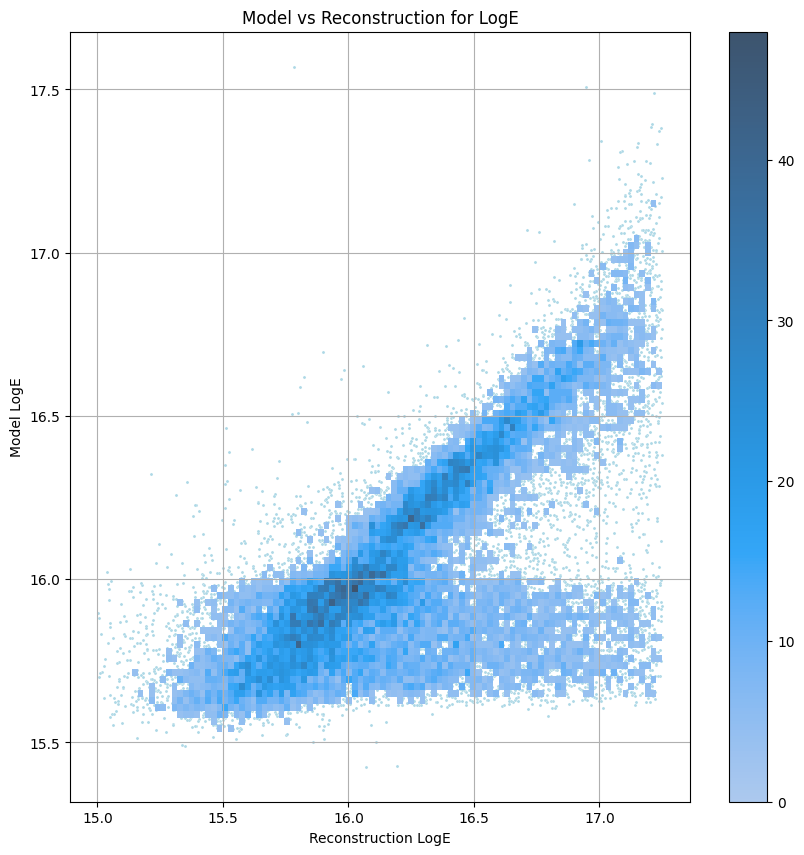

In [36]:
# Plotting Model vs Rec for Energy
plt.figure(figsize=(10,10))
X = Rec[:,1]
Y = Pred[:,1]


cut = (X>15) & (X<17.25)
X = X[cut]
Y = Y[cut]


sns.scatterplot(x=X, y=Y, s=5,color='lightblue')
sns.histplot(x=X, y=Y, bins=100, pthresh=0.1,cbar = True)


plt.xlabel('Reconstruction LogE')
plt.ylabel('Model LogE')
plt.title('Model vs Reconstruction for LogE')
plt.grid()

# Figuring out what are the wrong events

In [22]:
def GetMainDesc(Graph):
    # Unpack the Graph Datata to Main
    NEvents = len(Graph)
    if NEvents != 1: raise ValueError('GetMainDesc only works for single event')
    
    TraceMain = torch.zeros(NEvents,40   ,20,22)
    StartMain = torch.zeros(NEvents,1    ,20,22)
    Main      = torch.zeros(NEvents,2100 ,20,22) 
    # Have to allocate this massive tenosr to avoid memory issues
    # Maybe there is a better way to do this, but for now i cannot think of it.

    N_pixels_in_event = torch.tensor(list(map(len,map(lambda x : x[0], Graph)))).int()
    EventIndices      = torch.repeat_interleave(torch.arange(NEvents),N_pixels_in_event).int()

    Traces = torch.cat(list(map(lambda x : x[0], Graph)))
    Xs     = torch.cat(list(map(lambda x : x[1], Graph)))
    Ys     = torch.cat(list(map(lambda x : x[2], Graph)))
    Pstart = torch.cat(list(map(lambda x : x[3], Graph)))

    TraceMain[EventIndices,:,Xs,Ys] = Traces
    StartMain[EventIndices,0,Xs,Ys] = Pstart

    indices = (torch.arange(40).reshape(1,-1,1,1)+StartMain).long()
    Main.scatter_(1,indices,TraceMain)
    
    Main = Main[:,:40,:,:].unsqueeze(1).to(device)
    Main[torch.isnan(Main)] = -1

    # Has 1 Event, and 1 Channel so we can squeeze
    Main = Main.squeeze(0).squeeze(0).cpu()
    # Need to get number of active pixels
    # Already have that in N_pixels_in_event
    N_Bad_Values = torch.sum(Main==-1)
    # Need to get the length of the event, sum in spatial dimensions
    Main = Main.clip(0)
    Main_SpatialSum = torch.sum(Main,dim=(1,2))
    Lengths = torch.sum(Main_SpatialSum>0,dim=0)

    

    return [N_pixels_in_event.item(), Lengths.item(), N_Bad_Values.item()]




In [23]:
# Compute the Test Set
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = torch.device('cpu')
model.to(device)
torch.cuda.empty_cache()

Dataset.State      = 'Test'
# Dataset.BatchSize  = len(Dataset)//256
Dataset.BatchSize  = 1
Dataset.RandomIter = False
Truth = []
Pred  = []
Rec   = []
Aux   = []
Desc_Traces = []
Main_Desc = []

model.eval()
EvI = 0
with torch.no_grad():
    for EventIndex,BatchMains, BatchAux,BatchTruth,BatchRec in Dataset:
        # print(f'Event {EvI}/{len(Dataset)}', end='\r')
        # Send to device
        # BatchMains = [Main.to(device) for Main in BatchMains]
        # BatchAux   = BatchAux.to(device)
        # BatchAux[] = Dataset._Aux.mean(dim=0)

        this_Main_Desc = (GetMainDesc(BatchMains))
        Main_Desc.append(this_Main_Desc)
        Desc_Traces.append(torch.cat(list(map(lambda x : x[0], BatchMains))).flatten())
        # break
        Truth .append(BatchTruth)
        Pred  .append(model(BatchMains, BatchAux).cpu())
        Rec   .append(BatchRec)
        Aux   .append(BatchAux)
        EvI+=1

print()
Truth = torch.cat(Truth, dim=0)
Pred  = torch.cat(Pred , dim=0)
Rec   = torch.cat(Rec  , dim=0)
Aux   = torch.cat(Aux  , dim=0)

print(f'Pred Loss {MeanSquaredError(Truth,Pred)}')
print(f'Rec  Loss {MeanSquaredError(Truth,Rec )}')

Truth = Dataset.Unnormalise_Truth(Truth)
Pred  = Dataset.Unnormalise_Truth(Pred)
Rec   = Dataset.Unnormalise_Truth(Rec)


if len(Aux.shape) == 3:
    Aux = Aux.squeeze()  # Add a dimension if Aux is 1D

Truth = Truth.numpy()
Pred  = Pred .numpy()
Rec   = Rec  .numpy()
Aux   = Aux  .numpy()

Main_Desc = np.array(Main_Desc)

print(Truth.shape)
print(Pred.shape)
print(Rec.shape)
print(Aux.shape)

AuxKeys = ['Event_Class','Primary','Gen_LogE','Gen_CosZenith','Gen_Xmax','Gen_Chi0','Gen_Rp','AngularVelocity']
print('Auxiliary Keys:', AuxKeys)

KeyboardInterrupt: 

In [53]:
# Figuring out the default energy prediction of events

Pred_Xmax = Pred[:,0]
Pred_LogE = Pred[:,1]

Truth_Xmax = Truth[:,0]
Truth_LogE = Truth[:,1]

Rec_Xmax  = Rec [:,0]
Rec_LogE  = Rec [:,1]

# Create a mask of events which have a mean value for energy prediction where the true value isnt

Mask_Pred_default = (Pred_LogE > 16) & (Pred_LogE < 16.25)
Mask_Truth_mean   = (Truth_LogE < 15.75) | (Truth_LogE > 16.5)

Mask_Default = Mask_Pred_default & Mask_Truth_mean
Mask_NonDeft = ~Mask_Pred_default & Mask_Truth_mean


In [54]:
print(f'Number of Default Energy Predictions: {np.sum(Mask_Default)}')
print(f'Number of Non-Default Energy Predictions: {np.sum(Mask_NonDeft)}')

Number of Default Energy Predictions: 682
Number of Non-Default Energy Predictions: 5813


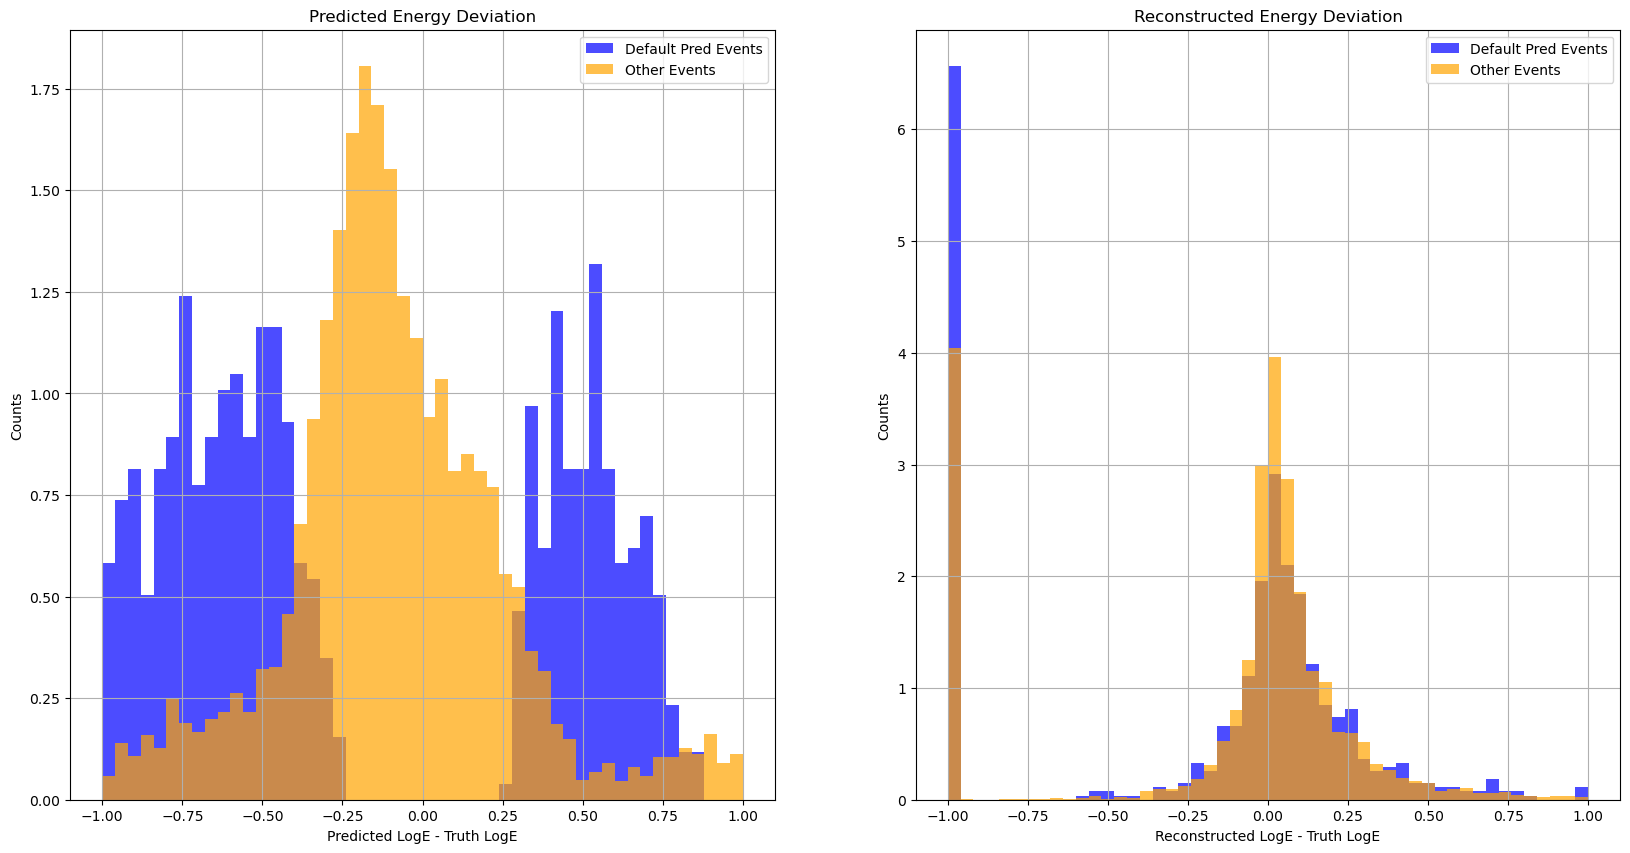

In [55]:
# lets see what the distribution of these events is for Rec First

fig, ax = plt.subplots(1,2,figsize=(20,10))

X = Pred_LogE - Truth_LogE

ax[0].hist(X[ Mask_Default], bins=50, range = [-1,1], color='blue', alpha=0.7, label='Default Pred Events',density=True)
ax[0].hist(X[ Mask_NonDeft], bins=50, range = [-1,1], color='orange', alpha=0.7, label='Other Events',density=True)
ax[0].set_title('Predicted Energy Deviation')
ax[0].set_xlabel('Predicted LogE - Truth LogE')
ax[0].set_ylabel('Counts')
ax[0].legend()
ax[0].grid()

# Now for Rec
X = Rec_LogE - Truth_LogE
# Set Nans to 0
X[np.isnan(X)|np.isinf(X)] = -1
ax[1].hist(X[ Mask_Default], bins=50, range = [-1,1], color='blue', alpha=0.7, label='Default Pred Events',density=True)
ax[1].hist(X[ Mask_NonDeft], bins=50, range = [-1,1], color='orange', alpha=0.7, label='Other Events',density=True)
ax[1].set_title('Reconstructed Energy Deviation')
ax[1].set_xlabel('Reconstructed LogE - Truth LogE')
ax[1].set_ylabel('Counts')
ax[1].legend()
ax[1].grid()


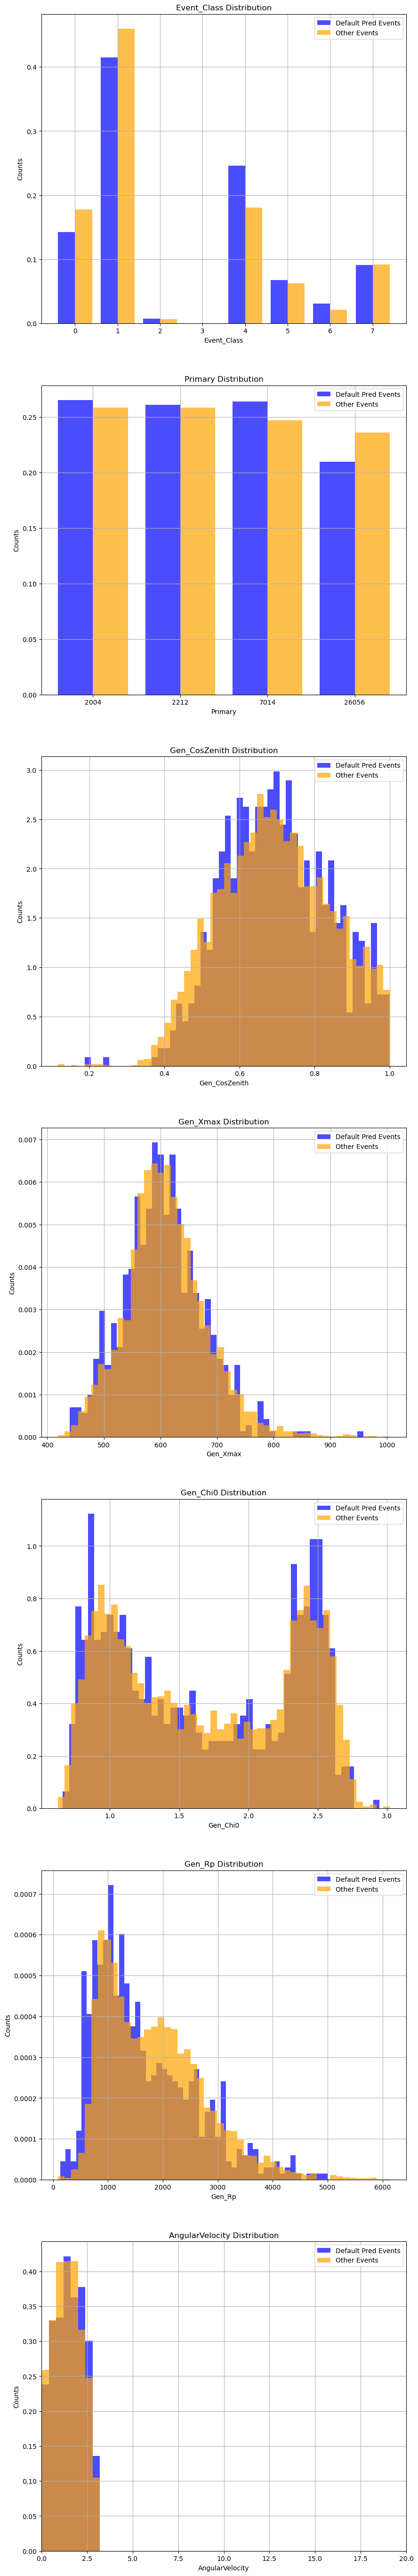

In [56]:
# now lets see how the aux variables of these events compare to the rest
Aux_vars_of_interest = ['Event_Class', 'Primary','Gen_CosZenith', 'Gen_Xmax', 'Gen_Chi0', 'Gen_Rp','AngularVelocity']

fig, ax = plt.subplots(len(Aux_vars_of_interest),1,figsize=(10,10*len(Aux_vars_of_interest)))
for i in range(len(Aux_vars_of_interest)):
    Var = Aux[:,AuxKeys.index(Aux_vars_of_interest[i])]
    if Aux_vars_of_interest[i] in ['Event_Class','Primary']:
        # Categorical Plot
        Categories = np.unique(Var)
        Counts_Default = [(Var[Mask_Default]==cat).sum() / Mask_Default.sum() for cat in Categories]
        Counts_Other   = [(Var[Mask_NonDeft]==cat).sum() / (Mask_NonDeft).sum() for cat in Categories]

        ax[i].bar(np.arange(len(Categories))-0.2, Counts_Default, width=0.4, color='blue', alpha=0.7, label='Default Pred Events')
        ax[i].bar(np.arange(len(Categories))+0.2, Counts_Other  , width=0.4, color='orange', alpha=0.7, label='Other Events')
        ax[i].set_xticks(np.arange(len(Categories)))
        ax[i].set_xticklabels([str(int(cat)) for cat in Categories])
        ax[i].set_xlabel(Aux_vars_of_interest[i])
        ax[i].set_ylabel('Counts')
        ax[i].set_title(f'{Aux_vars_of_interest[i]} Distribution')
        ax[i].legend()
        ax[i].grid()

        
    else:
        # Continuous Plot
        bin_range = None if Aux_vars_of_interest[i] != 'AngularVelocity' else (0,20)
        ax[i].hist(Var[ Mask_Default], bins=50, color='blue', alpha=0.7, label='Default Pred Events',density=True,range = bin_range)
        ax[i].hist(Var[Mask_NonDeft], bins=50, color='orange', alpha=0.7, label='Other Events',density=True,range = bin_range)
        ax[i].set_title(f'{Aux_vars_of_interest[i]} Distribution')
        ax[i].set_xlabel(Aux_vars_of_interest[i])
        ax[i].set_ylabel('Counts')
        ax[i].legend()
        ax[i].grid()
        if Aux_vars_of_interest[i] == 'AngularVelocity':
            ax[i].set_xlim(0,20)

# Comparing to old bad events

In [41]:
# Compute the Test Set
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = torch.device('cpu')
model.to(device)
torch.cuda.empty_cache()

Dataset.State      = 'Static'
# Dataset.BatchSize  = len(Dataset)//256
Dataset.BatchSize  = 64
Dataset.RandomIter = False

Old_Good_Event_Mask = Dataset._Good_Event_Mask
Dataset._Good_Event_Mask = None


print('Length of the Unfiltered Dataset:', len(Dataset))
Truth = []
Pred  = []
Rec   = []
Event_IDs = [ ]
model.eval()
EvI = 0
with torch.no_grad():
    for EventIndex,BatchMains, BatchAux,BatchTruth,BatchRec in Dataset:
        # print(f'Event {EvI}/{len(Dataset)}', end='\r')
        # Send to device
        # BatchMains = [Main.to(device) for Main in BatchMains]
        # BatchAux   = BatchAux.to(device)
        # BatchAux[] = Dataset._Aux.mean(dim=0)

        Truth .append(BatchTruth)
        Pred  .append(model(BatchMains, BatchAux).cpu())
        Rec   .append(BatchRec)
        Event_IDs.append(EventIndex)
        EvI+=1
print()
Truth = torch.cat(Truth, dim=0)
Pred  = torch.cat(Pred , dim=0)
Rec   = torch.cat(Rec  , dim=0)
Event_IDs = torch.cat(Event_IDs, dim=0)

print(f'Pred Loss {MeanSquaredError(Truth,Pred)}')
print(f'Rec  Loss {MeanSquaredError(Truth,Rec )}')

Truth = Dataset.Unnormalise_Truth(Truth)
Pred  = Dataset.Unnormalise_Truth(Pred)
Rec   = Dataset.Unnormalise_Truth(Rec)

# drop NaN values
if True:
    # Looking for nans, sum up all of 2nd dim
    WeirdSum = Truth.sum(dim=1) + Pred.sum(dim=1) + Rec.sum(dim=1)
    Mask = ~torch.isnan(WeirdSum)
    print(f'Dropping {len(Truth) - Mask.sum()} NaN values')
    Truth = Truth[Mask]
    Pred  = Pred [Mask]
    Rec   = Rec  [Mask]
    NanLocs = torch.where(Mask==0)
    print(f' Nan Locations {NanLocs}')

# Remove Bad events
if False:
    Mask = (torch.abs(Truth[:,0]-Rec[:,0]) < 1) & (torch.abs(Truth[:,1]-Rec[:,1]) < 1000)
    print(f'Dropping {len(Truth) - Mask.sum()} Bad events')
    Truth = Truth[Mask]
    Pred  = Pred [Mask]
    Rec   = Rec  [Mask]


Truth = Truth.numpy()
Pred  = Pred .numpy()
Rec   = Rec  .numpy()
Event_IDs = Event_IDs.numpy()


print(Truth.shape)
print(Pred.shape)

# Return the good event mask to its original state
Dataset._Good_Event_Mask = Old_Good_Event_Mask

Length of the Unfiltered Dataset: 375911

Pred Loss 0.7458698749542236
Rec  Loss inf
Dropping 0 NaN values
 Nan Locations (tensor([], dtype=torch.int64),)
(375911, 2)
(375911, 2)


In [42]:
def read_event_ids_from_file(filepath):
    IDs = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            # 'Batch_300001788:Shower_467'
            batch_part, shower_part = line.split(':')
            Part1 = int(batch_part.split('_')[1])  # e.g. 300001788
            Part2 = int(shower_part.split('_')[1]) # e.g. 467

            Part1 -= 300000000                     # reverse the offset
            ID = Part1 * 10000 + Part2
            IDs.append(ID)
    return np.array(IDs)

Default_Event_IDs_reconstructed    = read_event_ids_from_file('../../XmaxEnergy/Code/Default_Energy_Prediction_Event_IDs.txt')
NonDefault_Event_IDs_reconstructed = read_event_ids_from_file('../../XmaxEnergy/Code/NonDefault_Energy_Prediction_Event_IDs.txt')

In [43]:
Default_Event_IDs_reconstructed

array([862752789, 465521881, 289386044, ..., 372418792, 826018310,
       196666139])

In [44]:
Default_IDs_set = set(Default_Event_IDs_reconstructed)
Mask_Default_New = np.array([ID in Default_IDs_set for ID in Event_IDs])
print(f'Number of Default Energy Predictions (New Mask): {Mask_Default_New.sum()}')

Number of Default Energy Predictions (New Mask): 489


Total Points before cuts 489
Xmax Total Points after cuts 287
LogE Total Points after cuts 306


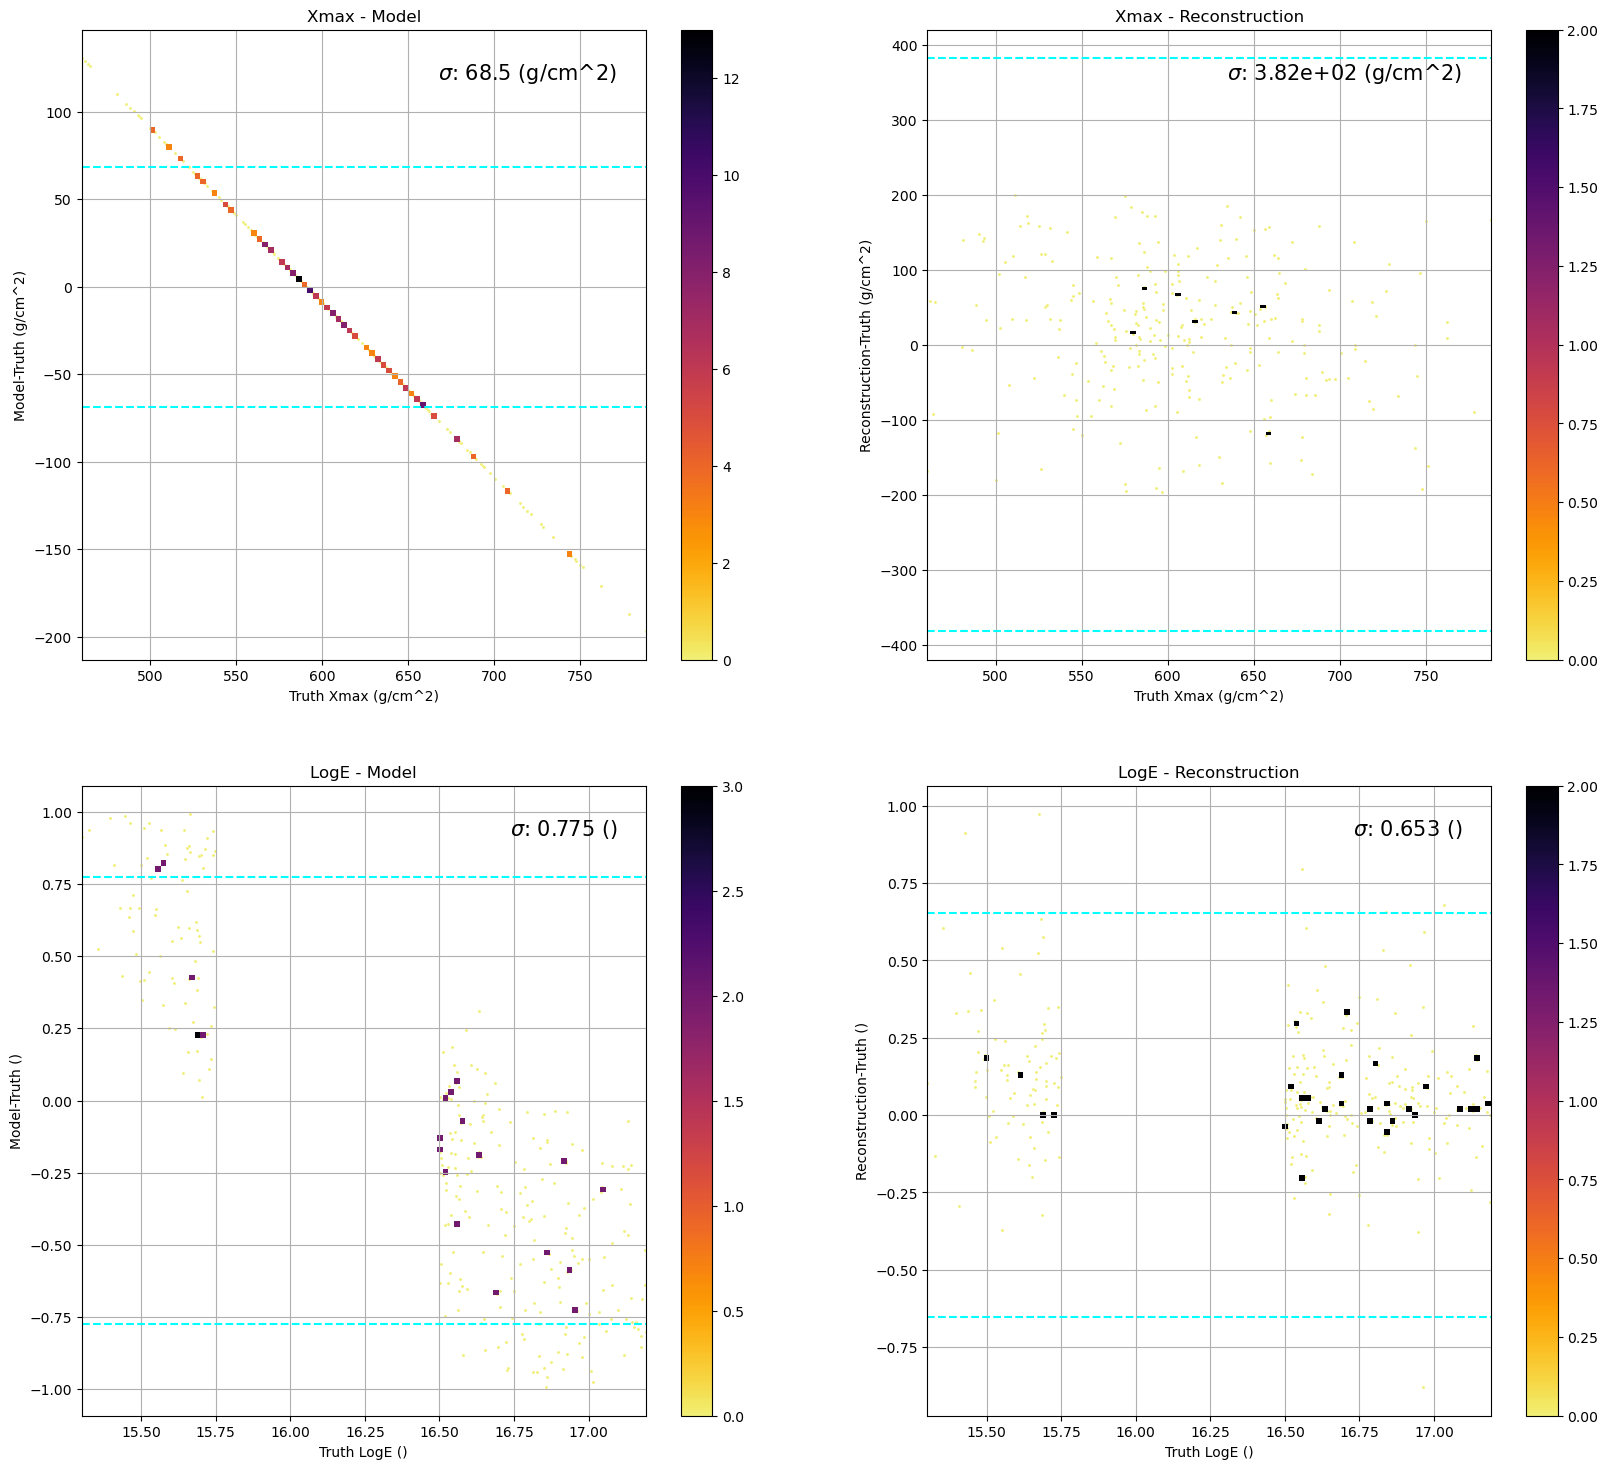

In [45]:
Def_Truth = Truth[Mask_Default_New]
Def_Pred  = Pred [Mask_Default_New]
Def_Rec   = Rec  [Mask_Default_New]

figure = CombinedDeviationPlots(TruthKeys,TruthUnits,Def_Truth,Def_Pred,Def_Rec,skip_cut=False)